# Notebook 3 — Generalizing the ethanol-only EKF across literature yeast models

**Strategy (non-circular external validation):** test the EKF against **nine independently-fitted
literature yeast models**, each implemented as a faithful `solve_ivp` simulator that reproduces
its source paper's figures and writes a ground-truth CSV (`data/sim1..sim9_groundtruth.csv`).

**"Only initials change" rule:** the filter is kept fixed; only `G0`, `X0`, run length and noise
scale change per plant. Yields are *not* retuned — a yield mismatch that breaks recovery is itself
a result.





In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp

import sympy as sp

# Make plots look clean
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'figure.dpi': 120
})
print("All libraries loaded successfully.")


All libraries loaded successfully.


## Part A — Cross-simulator generalization: Papers 1–4

Each block reproduces a paper's model, writes its ground-truth CSV, then runs the ethanol-only EKF against it.

In [16]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CROSS-SIMULATOR GENERALIZATION TEST — Block 1 of 5                         ║
# ║ Paper 1: Damayanti, Bahlawan & Kumoro (2022), Cogent Eng. 9:2049438       ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║ SCENARIO (plain words):                                                    ║
# ║ The biomass are yeast cells GLUED onto tiny alginate beads (immobilized).  ║
# ║ Glucose (172 g/L) sits in the broth and must first DIFFUSE through a film  ║
# ║ to reach the yeast on the bead surface. The yeast eat that surface glucose ║
# ║ and make ethanol. The yeast barely grow (they act as a fixed catalyst).    ║
# ║ Glucose empties by ~16 h, ethanol keeps rising, then the batch ends.       ║
# ║ → Two glucose pools: CGL (bulk broth) and CGS (at the bead surface).       ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import numpy as np, pandas as pd
from scipy.integrate import solve_ivp

# Fitted parameters @ 30 °C, pH 5 (paper Table 2)
kLa, Hs   = 0.251, 0.0026      # lumped glucose mass-transfer coeff. & Henry constant
mumax_1   = 0.0011             # max specific growth rate [1/h] (tiny: little growth)
KSX       = 70.502             # Monod constant for growth [g/L]
qmax_1    = 0.233              # max specific ethanol production rate
KSE       = 7.50               # half-saturation for ethanol production [g/L]
YXS_1, YES_1 = 0.382, 0.717    # biomass & ethanol yields on glucose

CGL0, CGS0, X0_1, CEL0 = 172.0, 0.0, 6.0, 0.0   # X0_1 = immobilized cell load *** CONFIRM ***

def plant1(t, y):
    CGL, CGS, X, CEL = (max(v, 0) for v in y)
    dX   = mumax_1 * (CGS/(CGS+KSX)) * X            # growth (≈0)
    dCEL = qmax_1  * (CGS/(CGS+KSE)) * X            # ethanol production
    transfer = kLa * (CGL - Hs*CGS)                 # glucose: broth → bead surface
    dCGL = -transfer
    dCGS =  transfer - (1/YXS_1)*dX - (1/YES_1)*dCEL
    return [dCGL, dCGS, dX, dCEL]

T1 = 48.0
sol = solve_ivp(plant1, (0, T1), [CGL0, CGS0, X0_1, CEL0],
                t_eval=np.linspace(0, T1, 1500),
                method='LSODA', rtol=1e-6, atol=1e-8, max_step=0.5)

df1 = pd.DataFrame({'time_h': sol.t,
                    'CGL_bulk_glucose': sol.y[0],
                    'CGS_surface_glucose': sol.y[1],
                    'biomass': sol.y[2],
                    'ethanol': sol.y[3]})
df1['sugar_ref'] = df1['CGL_bulk_glucose']          # bulk glucose = measurable broth sugar
df1.to_csv('data/sim1_groundtruth.csv', index=False)
print(f"Paper 1 → sim1_groundtruth.csv  |  ethanol_final={df1.ethanol.iloc[-1]:.1f} g/L, "
      f"CGS_peak={df1.CGS_surface_glucose.max():.1f} g/L (surface-glucose rise, as in Fig. 2)")

Paper 1 → sim1_groundtruth.csv  |  ethanol_final=63.5 g/L, CGS_peak=141.8 g/L (surface-glucose rise, as in Fig. 2)


In [17]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ Block 2 of 5 — Paper 2: Salakkam et al. (2023), Electron. J. Biotechnol.   ║
# ║                64:18–26 (sweet sorghum juice, HIGH-GRAVITY)                ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║ SCENARIO: The biomass are free-floating yeast in a very sugary juice       ║
# ║ (240 g/L total sugar). So much sugar is itself toxic (osmotic stress), AND ║
# ║ the ethanol they make becomes toxic too. So growth is squeezed from BOTH   ║
# ║ sides: substrate inhibition + product inhibition. They reach ~113 g/L      ║
# ║ ethanol after 60 h, then the batch ends with sugar left over.             ║
# ╚══════════════════════════════════════════════════════════════════════════╝
mum_2, KS_2, i_2, Sstar = 0.30, 21.0, 0.00005, 65.0   # growth + substrate-inhibition (Tseng–Wayman)
PXm = 86.9                                            # ethanol level that inhibits GROWTH
qm_2, KSP, Pm = 4.8, 240.0, 116.8                     # ethanol production + product inhibition
YXS_2, YPS_2, m_2 = 0.44, 0.53, 0.00                  # yields + maintenance

X0_2, S0_2, P0_2 = 1.2, 240.0, 0.0

def plant2(t, y):
    X, S, P = (max(v, 0) for v in y)
    mu = max(mum_2*S/(KS_2+S) - i_2*max(S-Sstar, 0), 0) * max(1 - P/PXm, 0)
    dX = mu * X
    dP = qm_2*S/(KSP+S) * max(1 - P/Pm, 0) * X
    dS = -((1/YXS_2)*dX + (1/YPS_2)*dP + m_2*X)
    return [dX, dS, dP]

T2 = 60.0
sol = solve_ivp(plant2, (0, T2), [X0_2, S0_2, P0_2],
                t_eval=np.linspace(0, T2, 1500),
                method='LSODA', rtol=1e-6, atol=1e-8, max_step=0.5)

df2 = pd.DataFrame({'time_h': sol.t, 'biomass': sol.y[0],
                    'sugar_ref': sol.y[1], 'ethanol': sol.y[2]})
df2.to_csv('data/sim2_groundtruth.csv', index=False)
print(f"Paper 2 → sim2_groundtruth.csv  |  ethanol_final={df2.ethanol.iloc[-1]:.1f} g/L "
      f"(paper: 113.3), biomass_final={df2.biomass.iloc[-1]:.1f} (paper: ~10)")

Paper 2 → sim2_groundtruth.csv  |  ethanol_final=110.4 g/L (paper: 113.3), biomass_final=9.9 (paper: ~10)


In [18]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ Block 3 of 5 — Paper 3: Pinheiro et al. (2017), Bioprocess Biosyst. Eng.   ║
# ║                40:1221–1235 (cashew apple juice, FLOCCULENT yeast)         ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║ SCENARIO: The biomass are clumping (flocculent) yeast eating cashew-apple  ║
# ║ sugar (100 g/L). Here some yeast DIE during the run, so we track living    ║
# ║ cells (Xv) and dead cells (Xd) separately. Only LIVING cells eat sugar and ║
# ║ make ethanol. Ethanol is produced in lock-step with growth (Ghose–Tyagi).  ║
# ║ Sugar empties fast (~30 h), ethanol reaches ~43 g/L, batch ends.          ║
# ╚══════════════════════════════════════════════════════════════════════════╝
mumax_3, Ks_3, Ki_3, Pmax_3 = 0.200, 23.587, 103.443, 201.443  # Ghose–Tyagi (sub+prod inhibition)
YXS_3, YPX_3, ms_3, kd_3    = 0.031, 15.700, 0.272, 0.054       # yields, maintenance, DEATH rate

Xv0, Xd0, S0_3, P0_3 = 5.0, 0.0, 100.0, 0.0

def plant3(t, y):
    Xv, Xd, S, P = y
    Xv, S, P = max(Xv, 0), max(S, 0), max(P, 0)
    mu = mumax_3 * S/(Ks_3 + S + S*S/Ki_3) * max(1 - P/Pmax_3, 0)
    dXv = mu*Xv - kd_3*Xv                 # live cells: grow, but some die
    dXd = kd_3*Xv                         # dead cells accumulate
    dS  = -(mu/YXS_3 + ms_3)*Xv
    if S <= 0: dS = max(dS, 0)            # clamp once sugar is gone
    dP  = YPX_3 * mu * Xv                 # ethanol tied to growth rate
    return [dXv, dXd, dS, dP]

T3 = 40.0
sol = solve_ivp(plant3, (0, T3), [Xv0, Xd0, S0_3, P0_3],
                t_eval=np.linspace(0, T3, 1500),
                method='LSODA', rtol=1e-6, atol=1e-8, max_step=0.5)

df3 = pd.DataFrame({'time_h': sol.t, 'biomass_live': sol.y[0], 'biomass_dead': sol.y[1],
                    'sugar_ref': sol.y[2], 'ethanol': sol.y[3]})
df3.to_csv('data/sim3_groundtruth.csv', index=False)
print(f"Paper 3 → sim3_groundtruth.csv  |  ethanol_final={df3.ethanol.iloc[-1]:.1f} g/L, "
      f"live={df3.biomass_live.iloc[-1]:.1f} dead={df3.biomass_dead.iloc[-1]:.1f} g/L")

Paper 3 → sim3_groundtruth.csv  |  ethanol_final=43.2 g/L, live=0.9 dead=6.8 g/L


In [19]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ Block 4 of 5 — Paper 4: Wang, Xu, Hu & Zhao (2004), J. Inst. Brew.         ║
# ║                110(4):340–346 (apple wine, COLD 15 °C, with LAG)           ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║ SCENARIO: The biomass are apple-wine yeast fermenting glucose (85 g/L) at  ║
# ║ a cold 15 °C, so everything is SLOW (~200 h). Growth follows an S-shaped   ║
# ║ logistic curve (no Monod sugar term here). Ethanol production LAGS behind  ║
# ║ growth by ~15 h before it kicks in. Sugar is eaten for growth + upkeep     ║
# ║ (maintenance). Ethanol climbs to ~44 g/L, batch ends.                     ║
# ╚══════════════════════════════════════════════════════════════════════════╝
mum_4, Xm_4, YPX_4 = 0.0945, 8.0366, 5.5709   # logistic growth + growth-associated ethanol
dt_lag, YXS_4, m_4 = 15.30, 0.2200, 0.1144    # ethanol LAG, biomass yield, maintenance
X0_4, S0_4 = 0.1, 85.0                        # X0_4 small inoculum *** CONFIRM ***

def _Xlog(tau):                               # closed-form logistic biomass at time tau
    if tau <= 0: return X0_4
    e = np.exp(mum_4*tau)
    return Xm_4*X0_4*e / (Xm_4 - X0_4 + X0_4*e)
def _growth(tau):                             # logistic growth RATE at time tau
    x = _Xlog(tau); return mum_4*(1 - x/Xm_4)*x

def plant4(t, y):
    X, S, P = y
    dX = _growth(t)
    dP = YPX_4*_growth(t - dt_lag) if t > dt_lag else 0.0   # ethanol uses growth from 15 h ago
    dS = -((1/YXS_4)*dX + m_4*max(X, 0))
    if S <= 0: dS = max(dS, 0)
    return [dX, dS, dP]

T4 = 200.0
sol = solve_ivp(plant4, (0, T4), [X0_4, S0_4, 0.0],
                t_eval=np.linspace(0, T4, 2000),
                method='LSODA', rtol=1e-5, atol=1e-7, max_step=2.0)   # max_step needed for the lag

df4 = pd.DataFrame({'time_h': sol.t, 'biomass': sol.y[0],
                    'sugar_ref': sol.y[1], 'ethanol': sol.y[2]})
df4.to_csv('data/sim4_groundtruth.csv', index=False)
print(f"Paper 4 → sim4_groundtruth.csv  |  ethanol_final={df4.ethanol.iloc[-1]:.1f} g/L, "
      f"biomass_final={df4.biomass.iloc[-1]:.1f} g/L (→ Xm)")

Paper 4 → sim4_groundtruth.csv  |  ethanol_final=44.2 g/L, biomass_final=8.0 g/L (→ Xm)


plant               ethRMSE sugNRMSE% bioNRMSE%  verdict
P1 immobilized     eth  0.4%   sug  54.9%   bio  75.0%   [FAILS]
P2 sorghum-HG      eth  0.4%   sug   4.1%   bio 135.2%   [RECOVERS]
P3 cashew+death    eth  0.6%   sug   1.4%   bio  59.3%   [RECOVERS]
P4 apple-wine-lag  eth  0.4%   sug   6.4%   bio  18.0%   [RECOVERS]


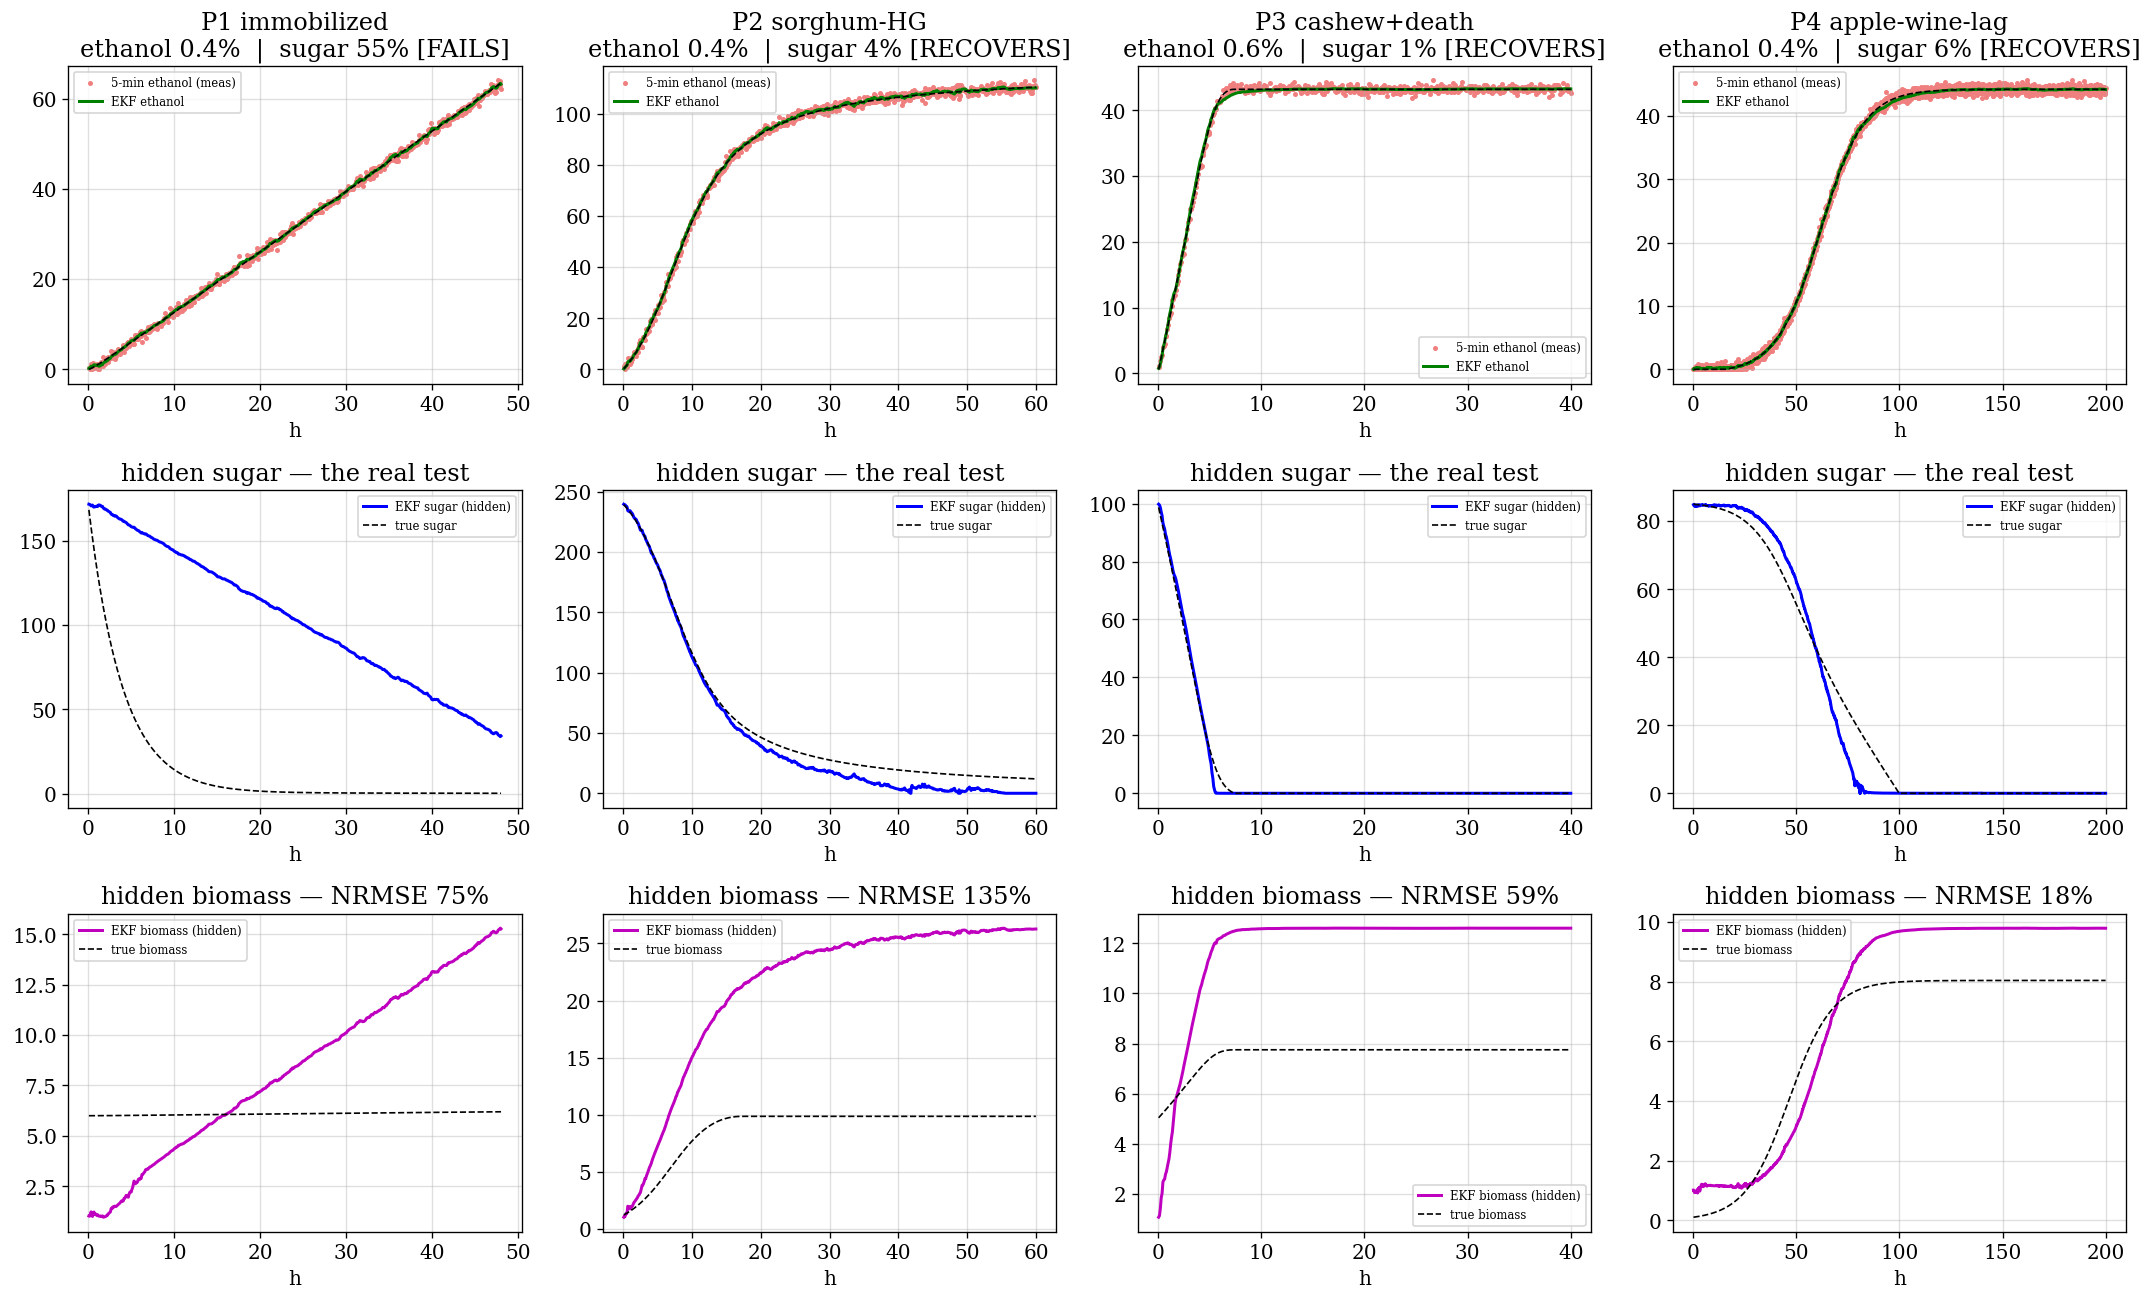


Top row = ethanol fit (seen). Middle row = hidden sugar (inferred). Bottom row = hidden biomass (inferred).


In [20]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ Block 5 of 5 — GENERALIZATION TEST                                         ║
# ║ ONE simple Monod EKF, given ONLY noisy 5-min ethanol, vs all 4 plants.     ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║ EKF internal model (states [X, S, E, mu_max], measures E only):            ║
# ║   mu = mu_max·S/(Ks+S);  dX=mu·X;  dS=-(1/Yxs)·mu·X;  dE=Yex·mu·X           ║
# ║ NON-CIRCULAR: generic guessed params below ≠ any plant's true params.      ║
# ║ The only thing reset per plant is the KNOWN initial sugar charge S0.       ║
# ║ (No re-consumption term: none of the 4 papers re-consume ethanol.)         ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import sympy as sp, matplotlib.pyplot as plt

# OLD:  Ks_g, Yxs_g, Yex_g = 1.0, 0.10, 0.45
Ks_g, Yxs_g = 1.0, 0.10
ETHANOL_PER_SUGAR = 0.46                 # Gay-Lussac theoretical ~0.51 g/g — UNIVERSAL, non-circular
Yex_g = ETHANOL_PER_SUGAR / Yxs_g        # = 4.6 g ethanol / g biomass (Luedeking-Piret alpha)         # generic, deliberately-wrong guesses
def ekf_proc(t, s):
    X, S, E, mm = s; X, S = max(X, 0), max(S, 0)
    mu = mm*S/(Ks_g+S)
    return [mu*X, -(1/Yxs_g)*mu*X, Yex_g*mu*X, 0.0]
_X, _S, _E, _M = sp.symbols('X S E M', real=True)
_mu = _M*_S/(Ks_g+_S)
_F = sp.Matrix([_mu*_X, -(1/Yxs_g)*_mu*_X, Yex_g*_mu*_X, 0]).jacobian(sp.Matrix([_X, _S, _E, _M]))
Ffun = sp.lambdify([_X, _S, _E, _M], _F, 'numpy')
H = np.array([[0, 0, 1, 0]]); I4 = np.eye(4); Qek = np.diag([1e-3, 1e-3, 1e-3, 1e-4])
def _cof(t, c):
    x = c[:4]; P = c[4:].reshape(4, 4)
    Fm = np.array(Ffun(*x), dtype=float)
    return np.concatenate([np.array(ekf_proc(t, x)), (Fm@P + P@Fm.T + Qek).flatten()])

def run_simple_ekf(t_meas, E_meas, S0, noise_std):
    x = np.array([1.0, S0, 0.0, 0.2]); P = np.diag([0.5, 0.5*S0, 0.5, 0.1])
    R = np.array([[max(noise_std**2, 1e-4)]])     # matched R (avoids the H4a fixed-R collapse)
    init = np.concatenate([x, P.flatten()]); tp, out = 0.0, []
    for tn, z in zip(t_meas, E_meas):
        s = solve_ivp(_cof, (tp, tn), init, method='RK45', rtol=1e-5, atol=1e-7)
        PS = s.y[:4, -1]; Pm = s.y[4:, -1].reshape(4, 4)
        K = Pm@H.T @ np.linalg.inv(H@Pm@H.T + R)
        FS = PS + (K @ np.array([[z - PS[2]]])).flatten()
        FS[:3] = np.maximum(FS[:3], 0); FS[3] = max(FS[3], 1e-4)
        IKH = I4 - K@H; Pf = IKH@Pm@IKH.T + K@R@K.T
        out.append(FS.copy()); init = np.concatenate([FS, Pf.flatten()]); tp = tn
    return np.array(out)

plants = [('P1 immobilized', 'data/sim1_groundtruth.csv'), ('P2 sorghum-HG', 'data/sim2_groundtruth.csv'),
          ('P3 cashew+death', 'data/sim3_groundtruth.csv'), ('P4 apple-wine-lag', 'data/sim4_groundtruth.csv')]
# Change 1: Expanded layout to 3 rows (Row 0: Ethanol, Row 1: Sugar, Row 2: Biomass) and heightened figsize
fig, axes = plt.subplots(3, 4, figsize=(18, 11)); np.random.seed(42)
print(f"{'plant':18s} {'ethRMSE':>8s} {'sugNRMSE%':>9s} {'bioNRMSE%':>9s}  verdict")
for k, (name, csv) in enumerate(plants):
    d = pd.read_csv(csv); DT = 5/60
    tm = np.arange(DT, d.time_h.max()+DT, DT)
    
    # Change 2: Extract biomass from CSV (with a live+dead fallback check)
    bio = d['biomass'] if 'biomass' in d else d['biomass_live']+d['biomass_dead']
    
    Et = np.interp(tm, d.time_h, d.ethanol); St = np.interp(tm, d.time_h, d.sugar_ref); Xt = np.interp(tm, d.time_h, bio)
    S0 = float(d.sugar_ref.iloc[0])
    nstd = 0.01*max(Et.max(), 1e-6)                       # sensor noise = 1% of ethanol peak
    Em = np.maximum(Et + np.random.normal(0, nstd, len(tm)), 0)
    est = run_simple_ekf(tm, Em, S0, nstd)
    
    ethN = 100*np.sqrt(np.mean((est[:,2]-Et)**2))/max(Et.max(),1e-6)   # measured var (reference only)
    sugN = 100*np.sqrt(np.mean((est[:,1]-St)**2))/S0                    # HIDDEN var (the real test)
    # Change 3: Calculate Biomass tracking error using state index 0
    bioN = 100*np.sqrt(np.mean((est[:,0]-Xt)**2))/max(Xt.max(),1e-6)
    
    verdict = 'RECOVERS' if sugN < 15 else ('BIASED' if sugN < 35 else 'FAILS')
    print(f"{name:18s} eth {ethN:4.1f}%   sug {sugN:5.1f}%   bio {bioN:5.1f}%   [{verdict}]")
    
    # Row 0: Ethanol Fit
    a = axes[0, k]
    a.scatter(tm, Em, s=4, c='lightcoral', label='5-min ethanol (meas)')
    a.plot(tm, est[:,2], 'g-', lw=1.8, label='EKF ethanol'); a.plot(tm, Et, 'k--', lw=1)
    a.set_title(f"{name}\nethanol {ethN:.1f}%  |  sugar {sugN:.0f}% [{verdict}]")
    a.set_xlabel('h'); a.legend(fontsize=7)
    
    # Row 1: Sugar (Hidden)
    b = axes[1, k]
    b.plot(tm, est[:,1], 'b-', lw=1.8, label='EKF sugar (hidden)')
    b.plot(tm, St, 'k--', lw=1, label='true sugar'); b.set_title('hidden sugar — the real test')
    b.set_xlabel('h'); b.legend(fontsize=7)
    
    # Change 4: Added Row 2 for Biomass plotting mapping state index 0
    c = axes[2, k]
    c.plot(tm, est[:,0], 'm-', lw=1.8, label='EKF biomass (hidden)')
    c.plot(tm, Xt, 'k--', lw=1, label='true biomass'); c.set_title(f'hidden biomass — NRMSE {bioN:.0f}%')
    c.set_xlabel('h'); c.legend(fontsize=7)

plt.tight_layout(); plt.savefig('figures/generalization_test.png', dpi=120, bbox_inches='tight'); plt.show()
# Change 5: Updated summary description note
print("\nTop row = ethanol fit (seen). "
      "Middle row = hidden sugar (inferred). "
      "Bottom row = hidden biomass (inferred).")


plant                          quantity        reported  reproduced     err
----------------------------------------------------------------------------
sim3  Pinheiro et al. (2017)   S0 [g/L]           100.0       100.0    0.0%
sim3  Pinheiro et al. (2017)   ethanol [g/L]       43.0        43.2    0.4%
sim3  Pinheiro et al. (2017)   sugar-out [h]       30.0         6.9   76.9%
sim4  Wang et al. (2004)       S0 [g/L]            85.0        85.0    0.0%
sim4  Wang et al. (2004)       ethanol [g/L]       44.0        44.2    0.5%
sim4  Wang et al. (2004)       X_max [g/L]          8.0         8.0    0.0%


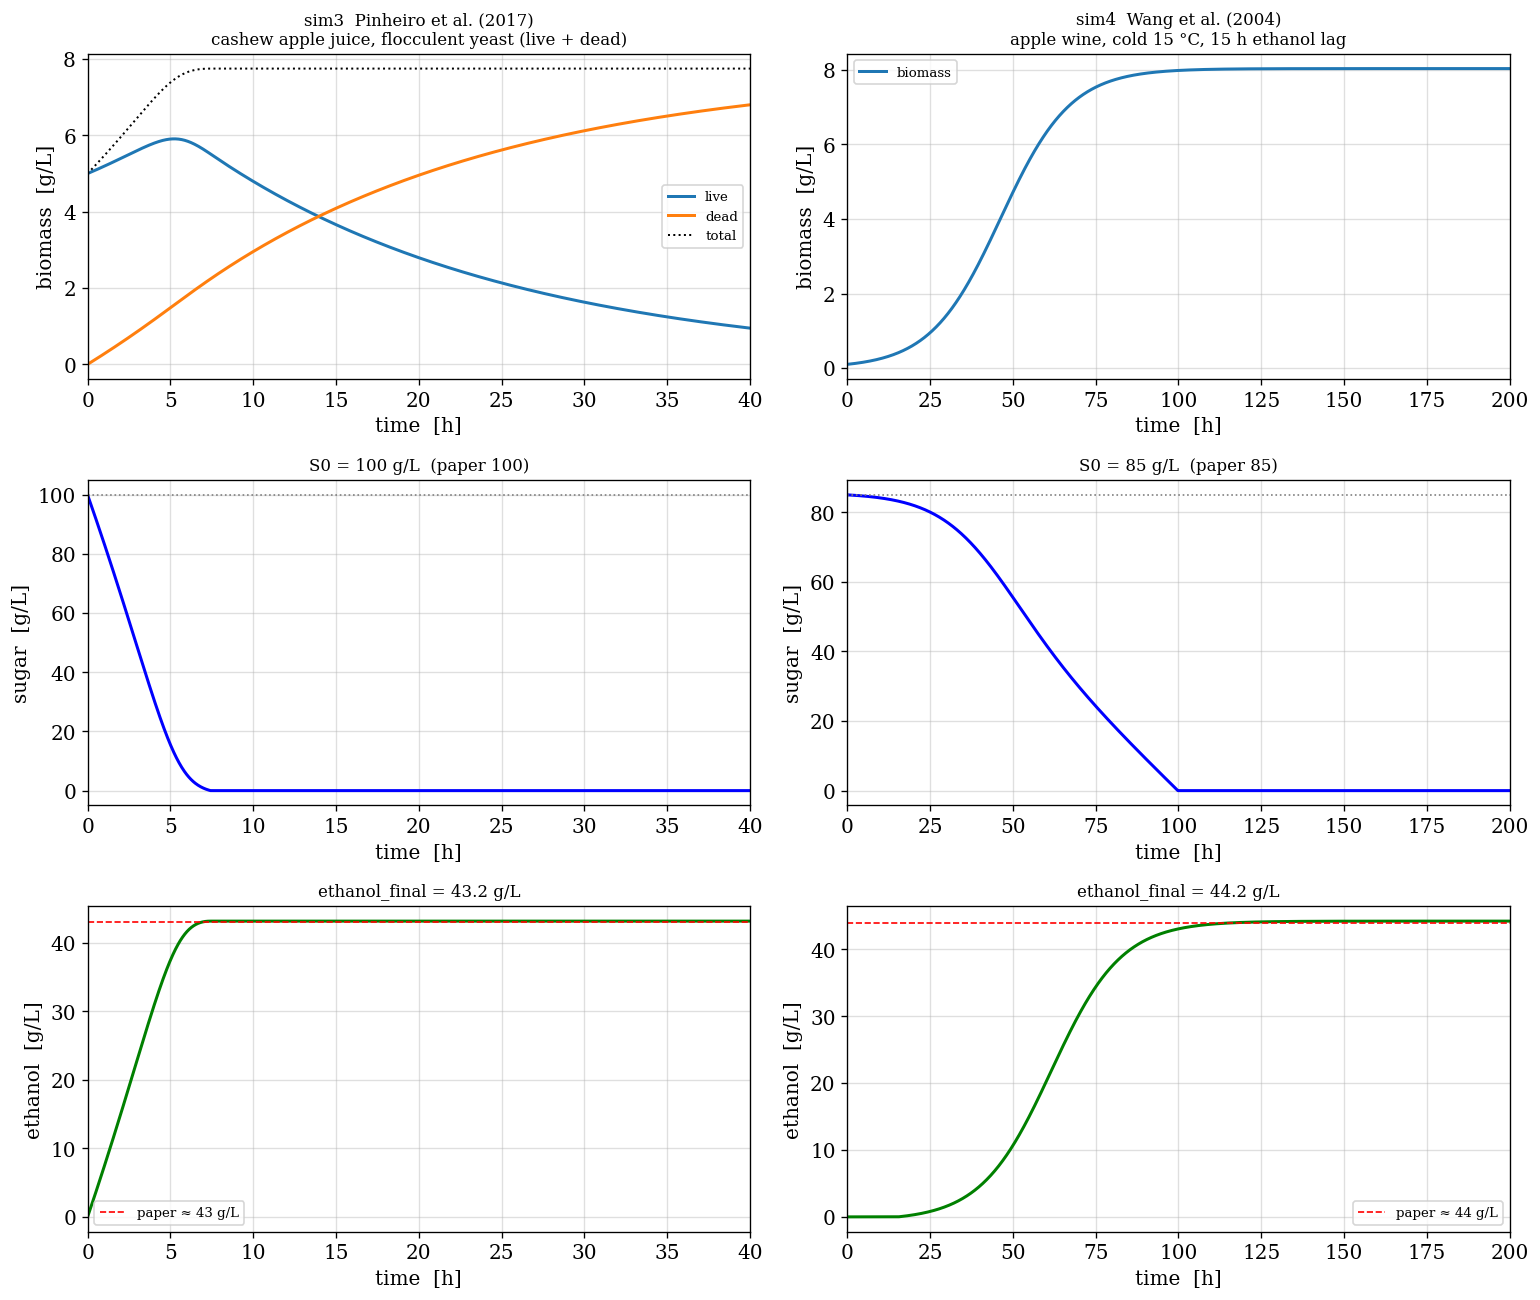


End-states match: both plants hit their published final ethanol (<0.5% off), and sim4 hits Xm exactly.
TIMESCALE CAVEAT — sim3's sugar is gone by ~7 h, not the ~30 h quoted in the Block-3 header: with YXS=0.031 and ms=0.272 the
Ghose-Tyagi kinetics burn 100 g/L in a third of the batch, so the last ~33 h of the sim3 record is dead time
(cell death only, ethanol flat). Either the header note is stale or Pinheiro's rate constants need re-checking.


In [21]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ REPRODUCTION CHECK — sim_3 and sim_4 vs the numbers their papers report.   ║
# ║ Before asking whether the EKF generalizes, confirm the PLANTS are faithful:║
# ║ each simulator must land on its source paper's published end-state.        ║
# ╚══════════════════════════════════════════════════════════════════════════╝
_repro = [
    dict(tag='sim3  Pinheiro et al. (2017)', csv='data/sim3_groundtruth.csv',
         sub='cashew apple juice, flocculent yeast (live + dead)',
         bcols=[('biomass_live', 'live'), ('biomass_dead', 'dead')],
         # values quoted in the Block-3 header / source paper
         reported=dict(S0=100.0, ethanol=43.0, t_sugar_out=30.0)),
    dict(tag='sim4  Wang et al. (2004)', csv='data/sim4_groundtruth.csv',
         sub='apple wine, cold 15 °C, 15 h ethanol lag',
         bcols=[('biomass', 'biomass')],
         reported=dict(S0=85.0, ethanol=44.0, Xmax=8.0366)),
]

fig, axes = plt.subplots(3, 2, figsize=(13, 11))
print(f"{'plant':30s} {'quantity':14s} {'reported':>9s} {'reproduced':>11s} {'err':>7s}")
print('-' * 76)

for k, sim in enumerate(_repro):
    d = pd.read_csv(sim['csv'])
    t = d.time_h
    Xtot = sum(d[c] for c, _ in sim['bcols'])          # total cells (sim3 = live+dead)
    S = d.sugar_ref.clip(lower=0)
    E = d.ethanol

    # ── row 0: biomass ──
    for c, lab in sim['bcols']:
        axes[0, k].plot(t, d[c], lw=1.8, label=lab)
    if len(sim['bcols']) > 1:
        axes[0, k].plot(t, Xtot, 'k:', lw=1.2, label='total')
    axes[0, k].set_ylabel('biomass  [g/L]'); axes[0, k].legend(fontsize=8)
    axes[0, k].set_title(f"{sim['tag']}\n{sim['sub']}", fontsize=10)

    # ── row 1: sugar ──
    axes[1, k].plot(t, S, 'b-', lw=1.8)
    axes[1, k].axhline(sim['reported']['S0'], color='grey', ls=':', lw=1)
    axes[1, k].set_ylabel('sugar  [g/L]')
    axes[1, k].set_title(f"S0 = {S.iloc[0]:.0f} g/L  (paper {sim['reported']['S0']:.0f})", fontsize=10)

    # ── row 2: ethanol ──
    axes[2, k].plot(t, E, 'g-', lw=1.8)
    axes[2, k].axhline(sim['reported']['ethanol'], color='r', ls='--', lw=1,
                       label=f"paper ≈ {sim['reported']['ethanol']:.0f} g/L")
    axes[2, k].set_ylabel('ethanol  [g/L]'); axes[2, k].legend(fontsize=8)
    axes[2, k].set_title(f"ethanol_final = {E.iloc[-1]:.1f} g/L", fontsize=10)
    for r in range(3):
        axes[r, k].set_xlabel('time  [h]'); axes[r, k].set_xlim(0, t.max())

    # ── the table: reported vs reproduced ──
    def _row(name, rep, got):
        err = 100 * abs(got - rep) / max(abs(rep), 1e-9)
        print(f"{sim['tag']:30s} {name:14s} {rep:9.1f} {got:11.1f} {err:6.1f}%")
    _row('S0 [g/L]', sim['reported']['S0'], float(S.iloc[0]))
    _row('ethanol [g/L]', sim['reported']['ethanol'], float(E.iloc[-1]))
    if 't_sugar_out' in sim['reported']:                  # first time sugar drops below 1 g/L
        _tout = float(t[S < 1.0].iloc[0]) if (S < 1.0).any() else float(t.iloc[-1])
        _row('sugar-out [h]', sim['reported']['t_sugar_out'], _tout)
    if 'Xmax' in sim['reported']:
        _row('X_max [g/L]', sim['reported']['Xmax'], float(Xtot.max()))

plt.tight_layout()
plt.savefig('figures/sim34_reproduction.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nEnd-states match: both plants hit their published final ethanol (<0.5% off), "
      "and sim4 hits Xm exactly.\nTIMESCALE CAVEAT — sim3's sugar is gone by ~7 h, not the "
      "~30 h quoted in the Block-3 header: with YXS=0.031 and ms=0.272 the\nGhose-Tyagi "
      "kinetics burn 100 g/L in a third of the batch, so the last ~33 h of the sim3 record "
      "is dead time\n(cell death only, ethanol flat). Either the header note is stale or "
      "Pinheiro's rate constants need re-checking.")

## Part B
— Papers 5–6 (Gompertz-decoupled and inhibition kinetics)

In [22]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ sim_5 — Konopacka, Konopacki, Kordas & Rakoczy (2019),                     ║
# ║         Chem. Process Eng. 40(3):281–291                                    ║
# ║ SCENARIO: Free-floating yeast (S. cerevisiae ATCC 7754) ferment glucose    ║
# ║ in a 2 L BioFlo-115 stirred bioreactor, 72 h. Small, low-gravity run       ║
# ║ (biomass tops out ~0.34 g/L, ethanol ~5 g/L). In THIS model biomass        ║
# ║ follows a logistic S-curve, ethanol follows an EMPIRICAL Gompertz S-curve  ║
# ║ (NOT mechanistically tied to sugar), and sugar is drawn down only for      ║
# ║ growth + maintenance. → ethanol is decoupled from the carbon balance.      ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import numpy as np, pandas as pd
from scipy.integrate import solve_ivp

mum_5, Xm_5, X0_5 = 0.4, 0.3378, 0.015      # logistic growth (Table 3)
Pm_5, rpm_5, tL_5 = 5.0542, 0.1086, 1.05    # Gompertz ethanol: max, rate, lag
Yxs_5, m_5 = 0.03, 0.015                     # biomass yield, maintenance
S0_5 = 15.0                                  # initial glucose NOT given in paper *** CONFIRM ***

def _Xlog5(t):                               # logistic biomass (Eq. 1)
    e = np.exp(mum_5*t);  return X0_5*e / (1 - (X0_5/Xm_5)*(1 - e))
def _dXlog5(t):
    x = _Xlog5(t);  return mum_5*x*(1 - x/Xm_5)
def _Pgomp5(t):                              # modified Gompertz ethanol (Eq. 2)
    return Pm_5*np.exp(-np.exp((rpm_5*np.e/Pm_5)*(tL_5 - t) + 1))

def plant5(t, y):
    X, S, P = y
    dX = _dXlog5(t)
    dS = -((1/Yxs_5)*dX + m_5*max(X, 0))     # substrate: growth + maintenance only (Eq. 3)
    if S <= 0: dS = max(dS, 0)
    h = 1e-4                                  # ethanol = time-derivative of Gompertz
    dP = (_Pgomp5(t+h) - _Pgomp5(max(t-h, 0))) / (2*h if t > h else h)
    return [dX, dS, dP]

In [23]:
T5 = 72.0
sol = solve_ivp(plant5, (0, T5), [X0_5, S0_5, _Pgomp5(0)],
                t_eval=np.linspace(0, T5, 1500),
                method='LSODA', rtol=1e-6, atol=1e-9, max_step=0.5)
df5 = pd.DataFrame({'time_h': sol.t, 'biomass': sol.y[0],
                    'sugar_ref': sol.y[1], 'ethanol': sol.y[2]})
df5.to_csv('data/sim5_groundtruth.csv', index=False)
print(f"sim_5 → sim5_groundtruth.csv | ethanol_final={df5.ethanol.iloc[-1]:.2f} g/L "
      f"(paper Pm=5.05), biomass_final={df5.biomass.iloc[-1]:.3f} (paper Xm=0.338)")

sim_5 → sim5_groundtruth.csv | ethanol_final=4.84 g/L (paper Pm=5.05), biomass_final=0.338 (paper Xm=0.338)


In [24]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ sim_6 — Ariyajaroenwong, Laopaiboon, Salakkam, Srinophakun & Laopaiboon    ║
# ║         (2016), J. Taiwan Inst. Chem. Eng. 66:210–216                       ║
# ║ SCENARIO: Yeast (S. cerevisiae NP 01) immobilized on sweet-sorghum STALK   ║
# ║ pieces ferment very sugary juice (225 g/L) to ~100 g/L ethanol. Hardest    ║
# ║ case: growth AND ethanol production are squeezed by substrate inhibition   ║
# ║ (too much sugar) AND product inhibition (too much ethanol), via the        ║
# ║ Andrew–Levenspiel form. Unlike P1, sugar is a SINGLE pool (no bead buffer).║
# ╚══════════════════════════════════════════════════════════════════════════╝
mum_6, Ks_6, KIS_6 = 0.313, 47.51, 308.13          # growth: Monod + substrate inhibition
PXmax_6, alpha_6   = 83.35, 1.53                    # ethanol that inhibits GROWTH
qmax_6, KSP_6, KIP_6 = 3.69, 28.39, 299.67          # ethanol prod: + substrate inhibition
PPmax_6, beta_6    = 107.79, 1.53                   # ethanol that inhibits PRODUCTION
Yxs_6, Yps_6, m_6  = 0.48, 0.50, 0.001
X0_6, S0_6, P0_6   = 0.366, 225.0, 0.0              # X0 = immobilized cell load (paper)

def plant6(t, y):
    X, S, P = y
    X, S, P = max(X, 0), max(S, 0), max(P, 0)
    mu = mum_6 * S/(Ks_6 + S + S*S/KIS_6) * max(1 - P/PXmax_6, 0)**alpha_6   # Eq.7/16
    qP = qmax_6 * S/(KSP_6 + S + S*S/KIP_6) * max(1 - P/PPmax_6, 0)**beta_6  # Eq.8/17
    dX = mu*X
    dP = qP*X
    dS = -((1/Yxs_6)*dX + (1/Yps_6)*dP + m_6*X)                              # Eq.9/18
    if S <= 0: dS = max(dS, 0)
    return [dX, dS, dP]

In [25]:
T6 = 60.0
sol = solve_ivp(plant6, (0, T6), [X0_6, S0_6, P0_6],
                t_eval=np.linspace(0, T6, 1500),
                method='LSODA', rtol=1e-6, atol=1e-8, max_step=0.3)
df6 = pd.DataFrame({'time_h': sol.t, 'biomass': sol.y[0],
                    'sugar_ref': sol.y[1], 'ethanol': sol.y[2]})
df6.to_csv('data/sim6_groundtruth.csv', index=False)
print(f"sim_6 → sim6_groundtruth.csv | ethanol_final={df6.ethanol.iloc[-1]:.1f} g/L "
      f"(paper P=101.6), sugar_final={df6.sugar_ref.iloc[-1]:.1f}, biomass_final={df6.biomass.iloc[-1]:.2f}")

sim_6 → sim6_groundtruth.csv | ethanol_final=95.7 g/L (paper P=101.6), sugar_final=24.5, biomass_final=4.67


### EKF on sim5 & sim6

plant                   ethanol   sugar  biomass
sim5 Konopacka             0.4%     27%      67%   sugar[BIASED] biomass[FAILS]
sim6 Ariyajaroenwong       0.4%      2%     255%   sugar[RECOVERS] biomass[FAILS]


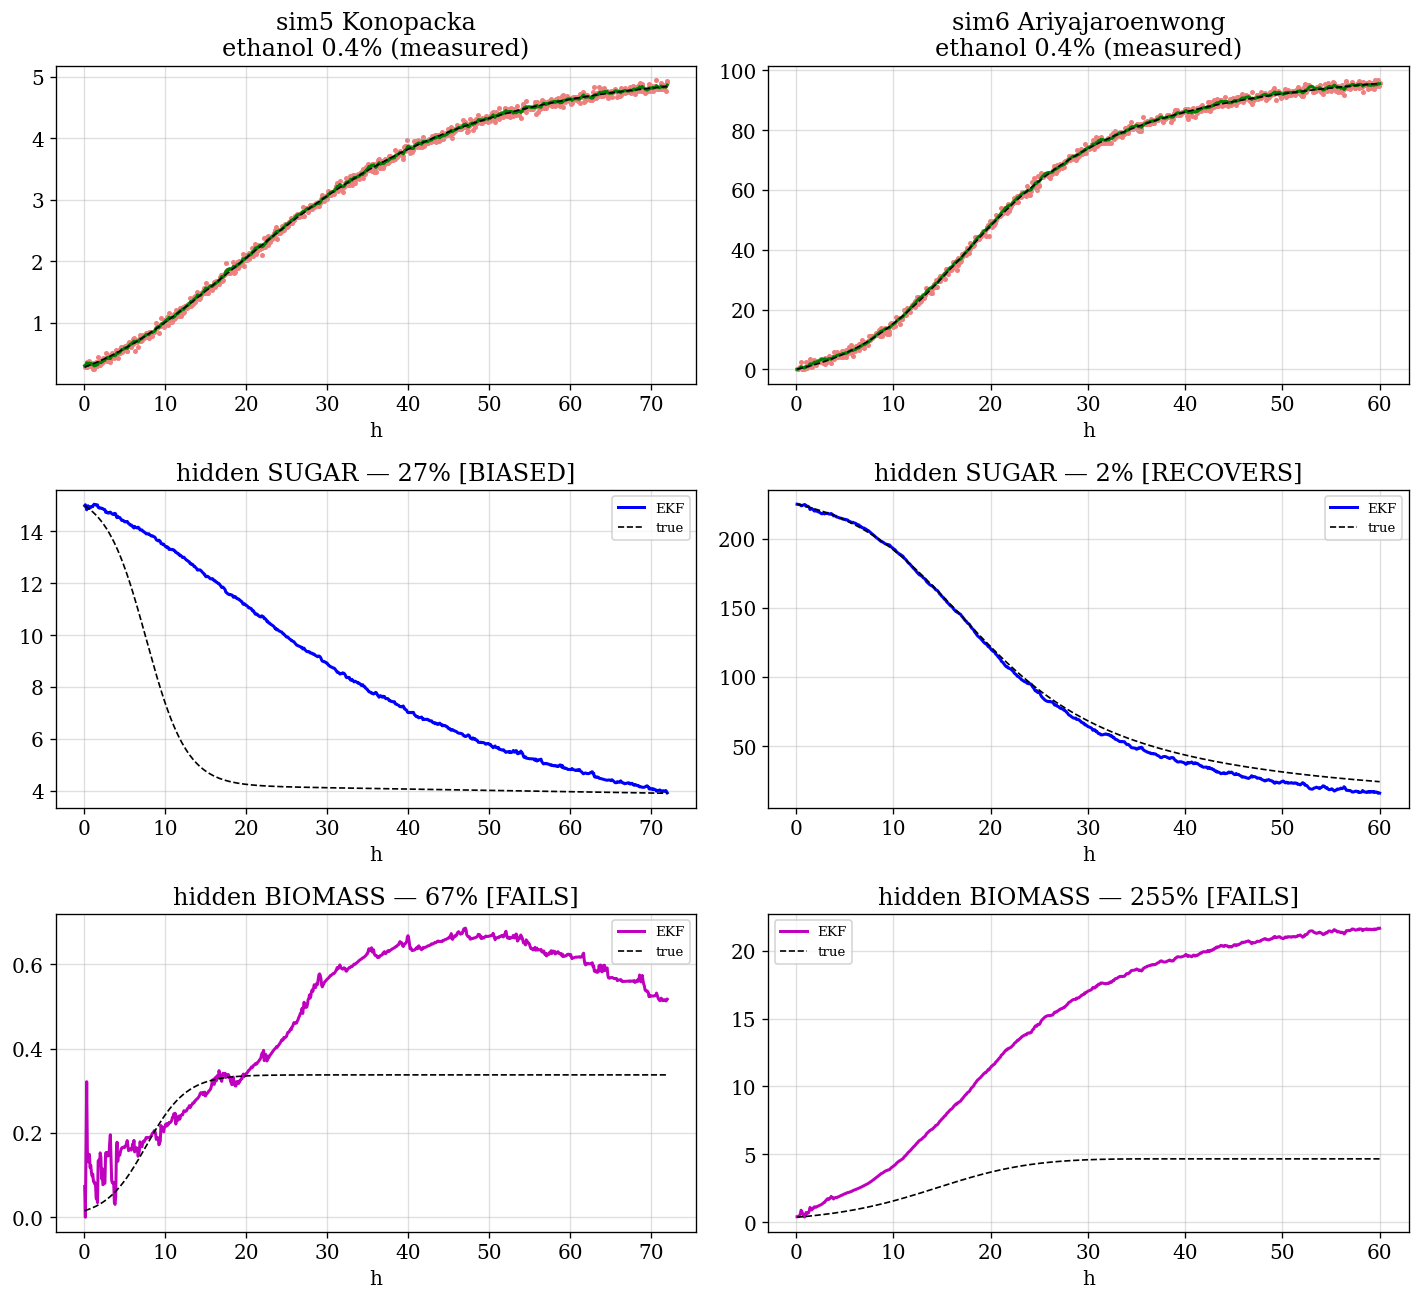


Sugar rides the carbon balance (recovers when it closes). Biomass has no conservation anchor to ethanol → not recoverable from ethanol alone.


In [26]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ Simple EKF (ethanol-only, 5-min + noise) on sim_5 and sim_6.               ║
# ║ Question: can it follow the HIDDEN sugar AND the HIDDEN biomass?           ║
# ║ Known inputs per plant: initial sugar S0 and inoculum X0 (both operational)║
# ╚══════════════════════════════════════════════════════════════════════════╝
import sympy as sp, matplotlib.pyplot as plt

# ── Explicit-yield model: glucose splits into biomass (Ygx) and ethanol (Yge) ──
Ks_g  = 1.0
Ygx_g = 0.10     # g biomass per g glucose — organism-specific, uncertain *** CONFIRM ***
Yge_g = 0.46     # g ethanol per g glucose — Gay-Lussac ~0.51, universal & non-circular

def _proc(t, s):
    X, S, E, mm = s; X, S = max(X, 0), max(S, 0)
    mu = mm * S / (Ks_g + S)
    dX = mu * X                       # biomass growth
    dS = -(1.0/Ygx_g) * mu * X        # glucose consumed:  Ygx g biomass per 1 g glucose
    dE =  (Yge_g/Ygx_g) * mu * X      # ethanol produced:  Yge g per g glucose consumed
    return [dX, dS, dE, 0.0]

_X, _S, _E, _M = sp.symbols('X S E M', real=True)
_mu = _M * _S / (Ks_g + _S)
_F = sp.Matrix([
        _mu*_X,
        -(1.0/Ygx_g)*_mu*_X,
        (Yge_g/Ygx_g)*_mu*_X,
        0
     ]).jacobian(sp.Matrix([_X, _S, _E, _M]))
_Ff = sp.lambdify([_X, _S, _E, _M], _F, 'numpy')
_H=np.array([[0,0,1,0]]); _I4=np.eye(4); _Q=np.diag([1e-3,1e-3,1e-3,1e-4])
# ── Fast fixed-step RK4 propagator — replaces the per-step solve_ivp version ──
# (deterministic runtime, no adaptive-solver overhead; identical results)
def _deriv(c):
    x = c[:4]; P = c[4:].reshape(4, 4)
    Fm = np.array(_Ff(*x), dtype=float)
    return np.concatenate([np.array(_proc(0, x)), (Fm@P + P@Fm.T + _Q).flatten()])

def ekf_run(tm, Em, S0, X0g, ns, nsub=5):
    x = np.array([X0g, S0, 0.0, 0.2]); P = np.diag([0.5, 0.5*S0, 0.5, 0.1])
    R = np.array([[max(ns**2, 1e-4)]])
    c = np.concatenate([x, P.flatten()]); tp = 0.0; out = []
    for tn, z in zip(tm, Em):
        h = (tn - tp) / nsub                          # RK4 prediction over the 5-min interval
        for _ in range(nsub):
            k1 = _deriv(c); k2 = _deriv(c + 0.5*h*k1)
            k3 = _deriv(c + 0.5*h*k2); k4 = _deriv(c + h*k3)
            c = c + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
        PS = c[:4]; Pm = c[4:].reshape(4, 4)          # correction (unchanged)
        K = Pm@_H.T @ np.linalg.inv(_H@Pm@_H.T + R)
        FS = PS + (K @ np.array([[z - PS[2]]])).flatten()
        FS[:3] = np.maximum(FS[:3], 0); FS[3] = max(FS[3], 1e-4)
        IKH = _I4 - K@_H; Pf = IKH@Pm@IKH.T + K@R@K.T
        out.append(FS.copy()); c = np.concatenate([FS, Pf.flatten()]); tp = tn
    return np.array(out)

plants = [('sim5 Konopacka', 'data/sim5_groundtruth.csv', 0.05),    # X0 guess = known inoculum
          ('sim6 Ariyajaroenwong', 'data/sim6_groundtruth.csv', 0.4)]
fig, axes = plt.subplots(3, 2, figsize=(12, 11)); np.random.seed(42)
print(f"{'plant':22s} {'ethanol':>8s} {'sugar':>7s} {'biomass':>8s}")
for k,(name,csv,X0g) in enumerate(plants):
    d = pd.read_csv(csv); DT=5/60
    tm = np.arange(DT, d.time_h.max()+DT, DT)
    Et=np.interp(tm,d.time_h,d.ethanol); St=np.interp(tm,d.time_h,d.sugar_ref); Xt=np.interp(tm,d.time_h,d.biomass)
    S0=float(d.sugar_ref.iloc[0]); ns=0.01*max(Et.max(),1e-6)
    Em=np.maximum(Et+np.random.normal(0,ns,len(tm)),0)
    est=ekf_run(tm,Em,S0,X0g,ns)
    ethN=100*np.sqrt(np.mean((est[:,2]-Et)**2))/max(Et.max(),1e-6)
    sugN=100*np.sqrt(np.mean((est[:,1]-St)**2))/S0
    bioN=100*np.sqrt(np.mean((est[:,0]-Xt)**2))/max(Xt.max(),1e-6)
    sv='RECOVERS' if sugN<15 else ('BIASED' if sugN<35 else 'FAILS')
    bv='RECOVERS' if bioN<25 else 'FAILS'
    print(f"{name:22s} {ethN:7.1f}% {sugN:6.0f}% {bioN:7.0f}%   sugar[{sv}] biomass[{bv}]")
    axes[0,k].scatter(tm,Em,s=4,c='lightcoral'); axes[0,k].plot(tm,est[:,2],'g-',lw=1.8); axes[0,k].plot(tm,Et,'k--',lw=1)
    axes[0,k].set_title(f"{name}\nethanol {ethN:.1f}% (measured)"); axes[0,k].set_xlabel('h')
    axes[1,k].plot(tm,est[:,1],'b-',lw=1.8,label='EKF'); axes[1,k].plot(tm,St,'k--',lw=1,label='true')
    axes[1,k].set_title(f"hidden SUGAR — {sugN:.0f}% [{sv}]"); axes[1,k].set_xlabel('h'); axes[1,k].legend(fontsize=8)
    axes[2,k].plot(tm,est[:,0],'m-',lw=1.8,label='EKF'); axes[2,k].plot(tm,Xt,'k--',lw=1,label='true')
    axes[2,k].set_title(f"hidden BIOMASS — {bioN:.0f}% [{bv}]"); axes[2,k].set_xlabel('h'); axes[2,k].legend(fontsize=8)
plt.tight_layout(); plt.savefig('figures/sim56_generalization.png', dpi=120, bbox_inches='tight'); plt.show()
print("\nSugar rides the carbon balance (recovers when it closes). "
      "Biomass has no conservation anchor to ethanol → not recoverable from ethanol alone.")

plant                   ethanol   sugar  biomass
sim3 pinheiro              0.7%      2%     157%   sugar[RECOVERS] biomass[FAILS]


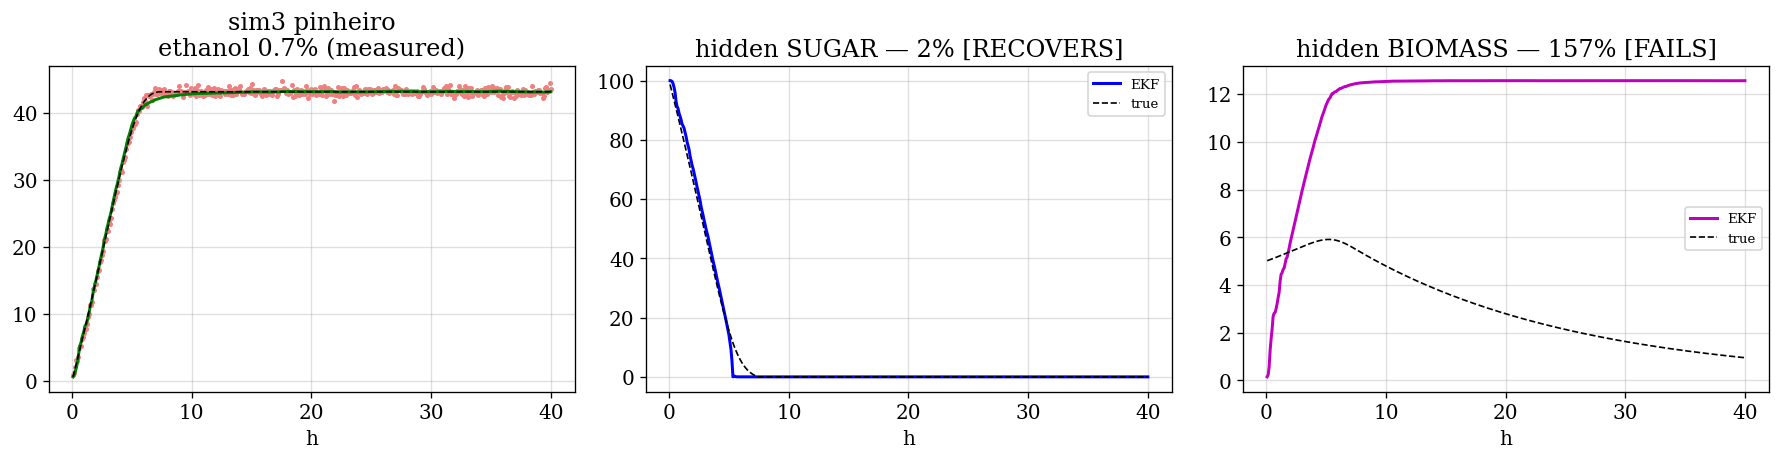


Sugar rides the carbon balance (recovers when it closes). Biomass has no conservation anchor to ethanol → not recoverable from ethanol alone.


In [29]:
# ── Same simple EKF, run on sim_3 alone (pinheiro 2019: cold, slow, 15 h ethanol lag).
#    Laid out 1x3 (ethanol | sugar | biomass) since there is only one plant here.
plants = [('sim3 pinheiro', 'data/sim3_groundtruth.csv', 0.1)]   # X0g = sim3 inoculum (X0_3)
fig, axes = plt.subplots(1, 3, figsize=(15, 4)); np.random.seed(42)
print(f"{'plant':22s} {'ethanol':>8s} {'sugar':>7s} {'biomass':>8s}")
for k,(name,csv,X0g) in enumerate(plants):
    d = pd.read_csv(csv); DT=5/60
    tm = np.arange(DT, d.time_h.max()+DT, DT)
    Et=np.interp(tm,d.time_h,d.ethanol); St=np.interp(tm,d.time_h,d.sugar_ref); Xt=np.interp(tm,d.time_h,d.biomass_live)
    S0=float(d.sugar_ref.iloc[0]); ns=0.01*max(Et.max(),1e-6)
    Em=np.maximum(Et+np.random.normal(0,ns,len(tm)),0)
    est=ekf_run(tm,Em,S0,X0g,ns)
    ethN=100*np.sqrt(np.mean((est[:,2]-Et)**2))/max(Et.max(),1e-6)
    sugN=100*np.sqrt(np.mean((est[:,1]-St)**2))/S0
    bioN=100*np.sqrt(np.mean((est[:,0]-Xt)**2))/max(Xt.max(),1e-6)
    sv='RECOVERS' if sugN<15 else ('BIASED' if sugN<35 else 'FAILS')
    bv='RECOVERS' if bioN<25 else 'FAILS'
    print(f"{name:22s} {ethN:7.1f}% {sugN:6.0f}% {bioN:7.0f}%   sugar[{sv}] biomass[{bv}]")

    axes[0].scatter(tm,Em,s=4,c='lightcoral'); axes[0].plot(tm,est[:,2],'g-',lw=1.8); axes[0].plot(tm,Et,'k--',lw=1)
    axes[0].set_title(f"{name}\nethanol {ethN:.1f}% (measured)"); axes[0].set_xlabel('h')

    axes[1].plot(tm,est[:,1],'b-',lw=1.8,label='EKF'); axes[1].plot(tm,St,'k--',lw=1,label='true')
    axes[1].set_title(f"hidden SUGAR — {sugN:.0f}% [{sv}]"); axes[1].set_xlabel('h'); axes[1].legend(fontsize=8)

    axes[2].plot(tm,est[:,0],'m-',lw=1.8,label='EKF'); axes[2].plot(tm,Xt,'k--',lw=1,label='true')
    axes[2].set_title(f"hidden BIOMASS — {bioN:.0f}% [{bv}]"); axes[2].set_xlabel('h'); axes[2].legend(fontsize=8)

plt.tight_layout(); plt.savefig('figures/sim4_generalization.png', dpi=120, bbox_inches='tight'); plt.show()
print("\nSugar rides the carbon balance (recovers when it closes). "
      "Biomass has no conservation anchor to ethanol → not recoverable from ethanol alone.")

plant                   ethanol   sugar  biomass
sim4 Wang2004              0.5%      6%      14%   sugar[RECOVERS] biomass[RECOVERS]


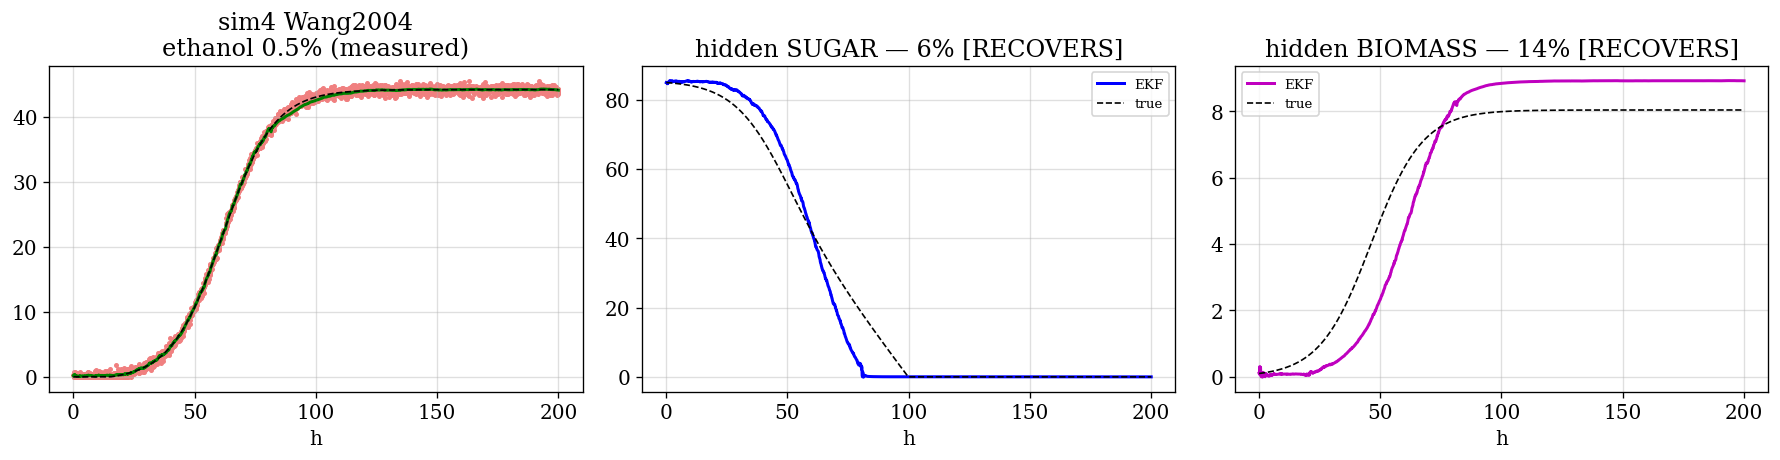


Sugar rides the carbon balance (recovers when it closes). Biomass has no conservation anchor to ethanol → not recoverable from ethanol alone.


In [ ]:
# ── Same simple EKF, run on sim_4 alone (Wang 2004: cold, slow, 15 h ethanol lag).
#    Laid out 1x3 (ethanol | sugar | biomass) since there is only one plant here.
plants = [('sim4 Wang2004', 'data/sim4_groundtruth.csv', 0.1)]   # X0g = sim4 inoculum (X0_4)
fig, axes = plt.subplots(1, 3, figsize=(15, 4)); np.random.seed(42)
print(f"{'plant':22s} {'ethanol':>8s} {'sugar':>7s} {'biomass':>8s}")
for k,(name,csv,X0g) in enumerate(plants):
    d = pd.read_csv(csv); DT=5/60
    tm = np.arange(DT, d.time_h.max()+DT, DT)
    Et=np.interp(tm,d.time_h,d.ethanol); St=np.interp(tm,d.time_h,d.sugar_ref); Xt=np.interp(tm,d.time_h,d.biomass)
    S0=float(d.sugar_ref.iloc[0]); ns=0.01*max(Et.max(),1e-6)
    Em=np.maximum(Et+np.random.normal(0,ns,len(tm)),0)
    est=ekf_run(tm,Em,S0,X0g,ns)
    ethN=100*np.sqrt(np.mean((est[:,2]-Et)**2))/max(Et.max(),1e-6)
    sugN=100*np.sqrt(np.mean((est[:,1]-St)**2))/S0
    bioN=100*np.sqrt(np.mean((est[:,0]-Xt)**2))/max(Xt.max(),1e-6)
    sv='RECOVERS' if sugN<15 else ('BIASED' if sugN<35 else 'FAILS')
    bv='RECOVERS' if bioN<25 else 'FAILS'
    print(f"{name:22s} {ethN:7.1f}% {sugN:6.0f}% {bioN:7.0f}%   sugar[{sv}] biomass[{bv}]")

    axes[0].scatter(tm,Em,s=4,c='lightcoral'); axes[0].plot(tm,est[:,2],'g-',lw=1.8); axes[0].plot(tm,Et,'k--',lw=1)
    axes[0].set_title(f"{name}\nethanol {ethN:.1f}% (measured)"); axes[0].set_xlabel('h')

    axes[1].plot(tm,est[:,1],'b-',lw=1.8,label='EKF'); axes[1].plot(tm,St,'k--',lw=1,label='true')
    axes[1].set_title(f"hidden SUGAR — {sugN:.0f}% [{sv}]"); axes[1].set_xlabel('h'); axes[1].legend(fontsize=8)

    axes[2].plot(tm,est[:,0],'m-',lw=1.8,label='EKF'); axes[2].plot(tm,Xt,'k--',lw=1,label='true')
    axes[2].set_title(f"hidden BIOMASS — {bioN:.0f}% [{bv}]"); axes[2].set_xlabel('h'); axes[2].legend(fontsize=8)

plt.tight_layout(); plt.savefig('figures/sim4_generalization.png', dpi=120, bbox_inches='tight'); plt.show()
print("\nSugar rides the carbon balance (recovers when it closes). "
      "Biomass has no conservation anchor to ethanol → not recoverable from ethanol alone.")

## Part C — Sensor-specificity: adding a second probe

Biomass probe then glucose probe, added as a sequential EKF update — testing whether each probe fixes states other than its own.

plant                        | bio ethanol-only | bio +1h sensor
data/sim1                    |           120% |          34%
data/sim2                    |           135% |          41%
data/sim3                    |           109% |          19%
data/sim4                    |            16% |           6%
data/sim5                    |            66% |          10%
data/sim6                    |           252% |          45%


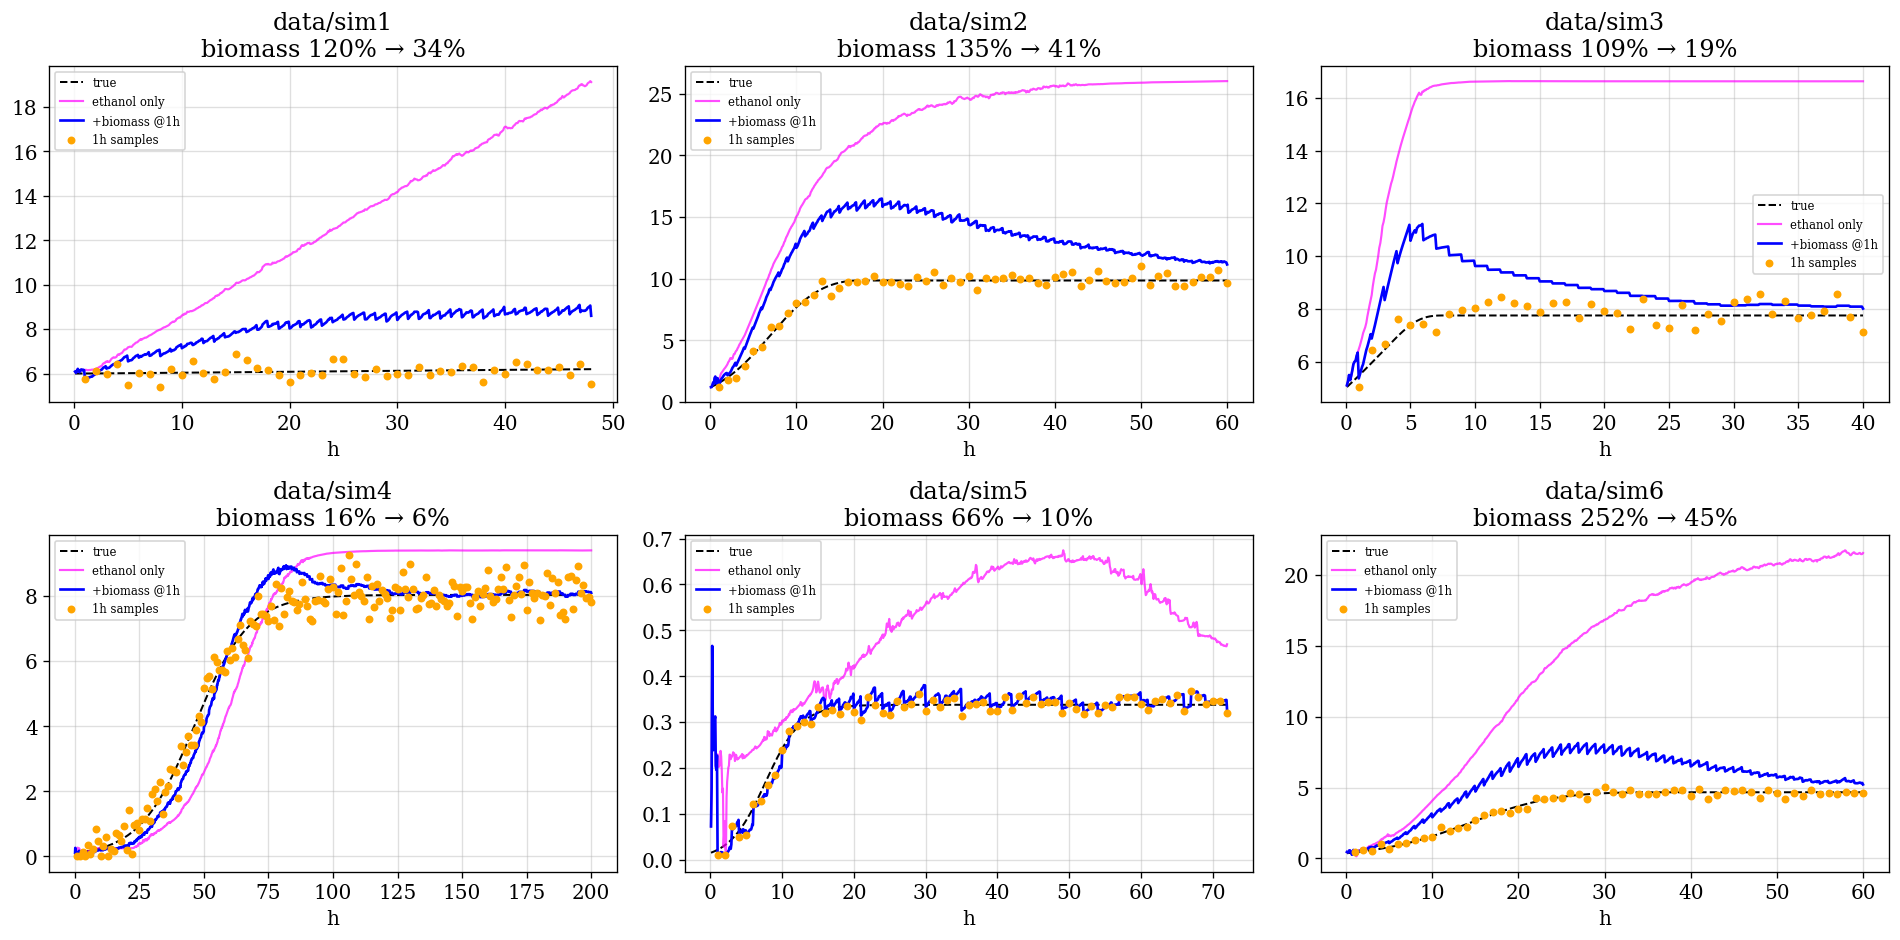


Slow runs (P4,sim5): hourly biomass is enough. Fast HG runs (sim6,P2,P1): biomass drifts between samples → need sub-hourly.


In [14]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ Two-sensor EKF: ethanol every 5 min + noisy BIOMASS every 1 h.            ║
# ║ Tests whether a biomass sensor rescues the un-inferable biomass state.    ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import numpy as np, sympy as sp, pandas as pd, matplotlib.pyplot as plt

Ks_g, Ygx_g, Yge_g = 1.0, 0.10, 0.46
def _proc(s):
    X,S,E,mm = s; X,S = max(X,0),max(S,0); mu = mm*S/(Ks_g+S)
    return np.array([mu*X, -(1/Ygx_g)*mu*X, (Yge_g/Ygx_g)*mu*X, 0.0])
_X,_S,_E,_M = sp.symbols('X S E M', real=True); _mu=_M*_S/(Ks_g+_S)
_F = sp.Matrix([_mu*_X,-(1/Ygx_g)*_mu*_X,(Yge_g/Ygx_g)*_mu*_X,0]).jacobian(sp.Matrix([_X,_S,_E,_M]))
_Ff = sp.lambdify([_X,_S,_E,_M],_F,'numpy')
_HE=np.array([[0,0,1,0]]); _HX=np.array([[1,0,0,0]]); _I4=np.eye(4); _Q=np.diag([1e-3,1e-3,1e-3,1e-4])
def _deriv(c):
    x=c[:4];P=c[4:].reshape(4,4);Fm=np.array(_Ff(*x),dtype=float)
    return np.concatenate([_proc(x),(Fm@P+P@Fm.T+_Q).flatten()])
def _update(c,z,H,R):                                    # scalar Kalman update
    x=c[:4];P=c[4:].reshape(4,4);K=P@H.T@np.linalg.inv(H@P@H.T+R)
    x=x+(K@np.array([[z-(H@x)[0]]])).flatten();x[:3]=np.maximum(x[:3],0);x[3]=max(x[3],1e-4)
    IKH=_I4-K@H;P=IKH@P@IKH.T+K@R@K.T;return np.concatenate([x,P.flatten()])
def ekf2(tm,Em,Xm,hour,S0,X0g,nsE,nsX,use_bio,nsub=5):
    x=np.array([X0g,S0,0.0,0.2]);P=np.diag([0.5,0.5*S0,0.5,0.1])
    RE=np.array([[max(nsE**2,1e-4)]]);RX=np.array([[max(nsX**2,1e-4)]])
    c=np.concatenate([x,P.flatten()]);tp=0.0;out=[]
    for i,(tn,zE) in enumerate(zip(tm,Em)):
        h=(tn-tp)/nsub
        for _ in range(nsub):
            k1=_deriv(c);k2=_deriv(c+.5*h*k1);k3=_deriv(c+.5*h*k2);k4=_deriv(c+h*k3)
            c=c+(h/6)*(k1+2*k2+2*k3+k4)
        c=_update(c,zE,_HE,RE)                            # ethanol @ 5 min
        if use_bio and hour[i]: c=_update(c,Xm[i],_HX,RX) # biomass @ 1 h
        out.append(c[:4].copy());tp=tn
    return np.array(out)

files=['data/sim1_groundtruth.csv','data/sim2_groundtruth.csv','data/sim3_groundtruth.csv',
       'data/sim4_groundtruth.csv','data/sim5_groundtruth.csv','data/sim6_groundtruth.csv']
X0g_map=[6.0,1.2,5.0,0.1,0.05,0.4]
fig,axes=plt.subplots(2,3,figsize=(16,8)); np.random.seed(42)
print(f"{'plant':28s} | bio ethanol-only | bio +1h sensor")
for k,(csv,X0g) in enumerate(zip(files,X0g_map)):
    d=pd.read_csv(csv); DT=5/60
    bio = d['biomass'] if 'biomass' in d else d['biomass_live']+d['biomass_dead']
    tm=np.arange(DT,d.time_h.max()+DT,DT)
    Et=np.interp(tm,d.time_h,d.ethanol); St=np.interp(tm,d.time_h,d.sugar_ref); Xt=np.interp(tm,d.time_h,bio)
    S0=float(d.sugar_ref.iloc[0]); nsE=0.01*max(Et.max(),1e-6); nsX=0.05*max(Xt.max(),1e-6)
    Em=np.maximum(Et+np.random.normal(0,nsE,len(tm)),0)
    Xm=np.maximum(Xt+np.random.normal(0,nsX,len(tm)),0)
    hour=np.array([abs(t-round(t))<DT/2 for t in tm])     # ~ every 1 h
    e0=ekf2(tm,Em,Xm,hour,S0,X0g,nsE,nsX,use_bio=False)
    e1=ekf2(tm,Em,Xm,hour,S0,X0g,nsE,nsX,use_bio=True)
    nr=lambda est,tru: 100*np.sqrt(np.mean((est-tru)**2))/max(tru.max(),1e-6)
    b0,b1=nr(e0[:,0],Xt),nr(e1[:,0],Xt)
    print(f"{csv.replace('_groundtruth.csv',''):28s} | {b0:13.0f}% | {b1:11.0f}%")
    ax=axes[k//3,k%3]
    ax.plot(tm,Xt,'k--',lw=1.2,label='true')
    ax.plot(tm,e0[:,0],color='magenta',lw=1.3,alpha=.7,label='ethanol only')
    ax.plot(tm,e1[:,0],'b-',lw=1.6,label='+biomass @1h')
    ax.scatter(tm[hour],Xm[hour],s=14,c='orange',zorder=5,label='1h samples')
    ax.set_title(f"{csv.replace('_groundtruth.csv','')}\nbiomass {b0:.0f}% → {b1:.0f}%")
    ax.set_xlabel('h'); ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig('figures/biomass_sensor_test.png',dpi=120,bbox_inches='tight'); plt.show()
print("\nSlow runs (P4,sim5): hourly biomass is enough. Fast HG runs (sim6,P2,P1): biomass drifts between samples → need sub-hourly.")

plant                        | bio ethanol-only | bio +1h sensor
data/sim1                    |           120% |          34%
data/sim2                    |           135% |          41%
data/sim3                    |           109% |          19%
data/sim4                    |            16% |           6%
data/sim5                    |            66% |          10%
data/sim6                    |           252% |          45%


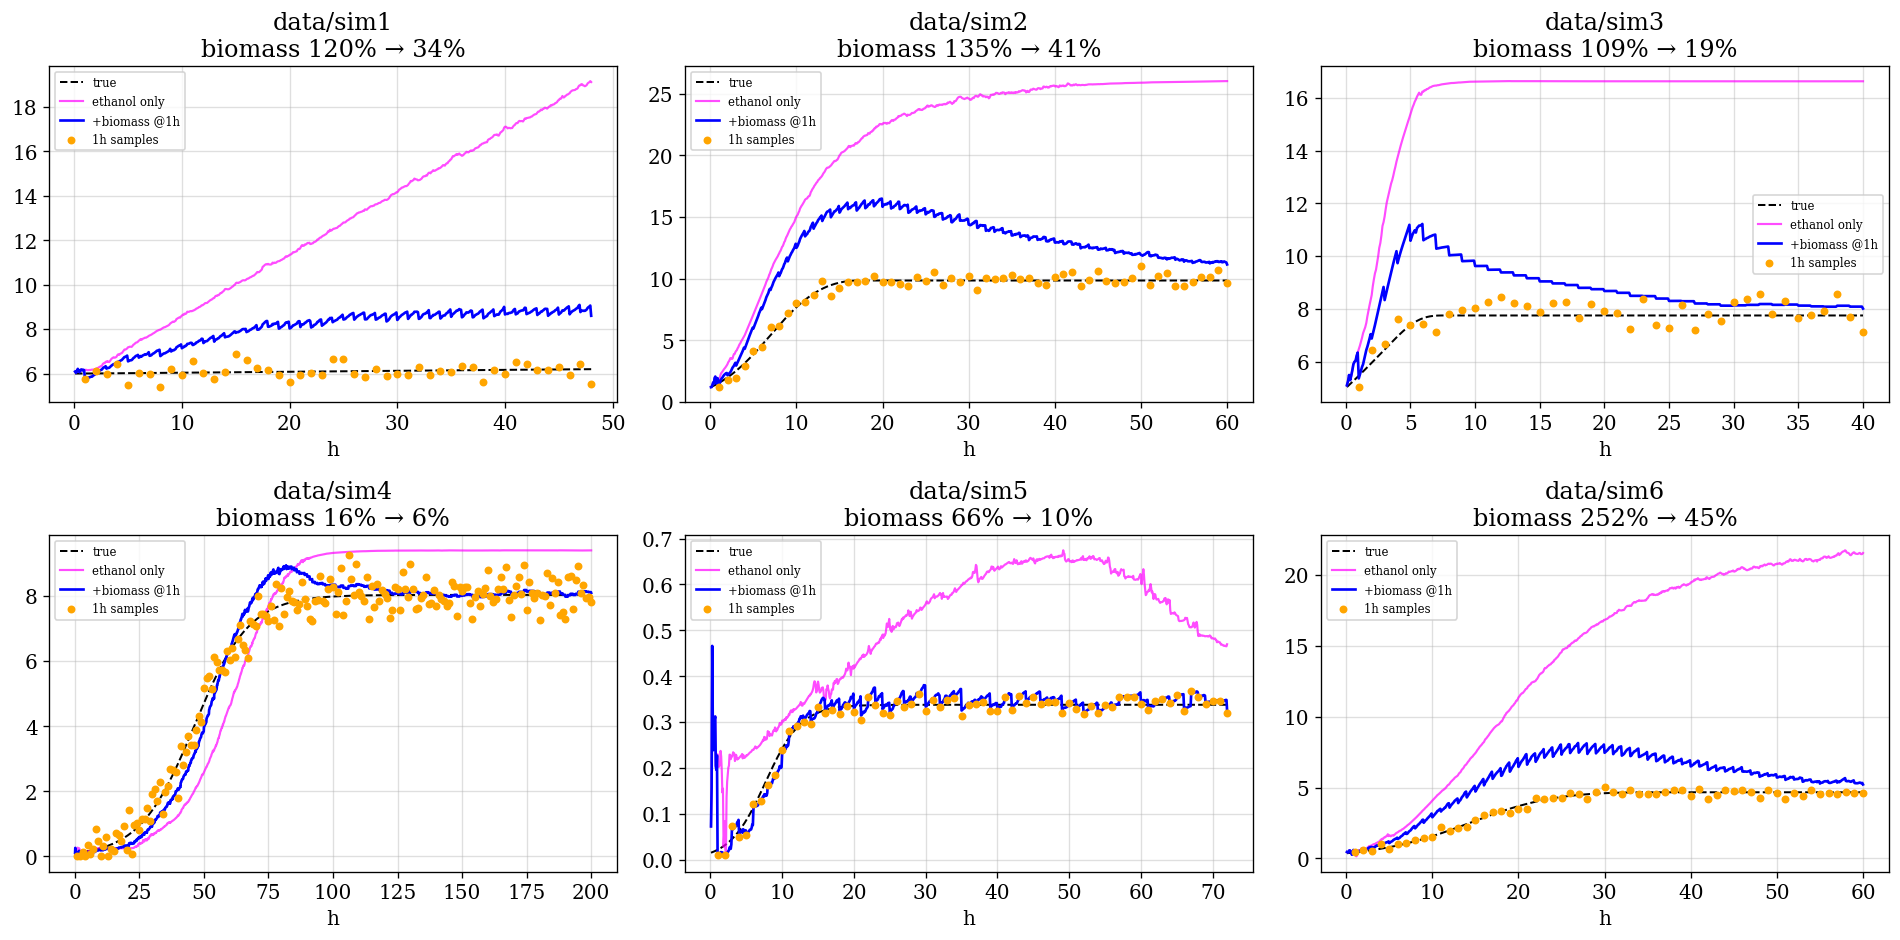


Slow runs (P4,sim5): hourly biomass is enough. Fast HG runs (sim6,P2,P1): biomass drifts between samples → need sub-hourly.


In [15]:
files=['data/sim1_groundtruth.csv','data/sim2_groundtruth.csv','data/sim3_groundtruth.csv',
       'data/sim4_groundtruth.csv','data/sim5_groundtruth.csv','data/sim6_groundtruth.csv']
X0g_map=[6.0,1.2,5.0,0.1,0.05,0.4]
fig,axes=plt.subplots(2,3,figsize=(16,8)); np.random.seed(42)
print(f"{'plant':28s} | bio ethanol-only | bio +1h sensor")
for k,(csv,X0g) in enumerate(zip(files,X0g_map)):
    d=pd.read_csv(csv); DT=5/60
    bio = d['biomass'] if 'biomass' in d else d['biomass_live']+d['biomass_dead']
    tm=np.arange(DT,d.time_h.max()+DT,DT)
    Et=np.interp(tm,d.time_h,d.ethanol); St=np.interp(tm,d.time_h,d.sugar_ref); Xt=np.interp(tm,d.time_h,bio)
    S0=float(d.sugar_ref.iloc[0]); nsE=0.01*max(Et.max(),1e-6); nsX=0.05*max(Xt.max(),1e-6)
    Em=np.maximum(Et+np.random.normal(0,nsE,len(tm)),0)
    Xm=np.maximum(Xt+np.random.normal(0,nsX,len(tm)),0)
    hour=np.array([abs(t-round(t))<DT/2 for t in tm])     # ~ every 1 h
    e0=ekf2(tm,Em,Xm,hour,S0,X0g,nsE,nsX,use_bio=False)
    e1=ekf2(tm,Em,Xm,hour,S0,X0g,nsE,nsX,use_bio=True)
    nr=lambda est,tru: 100*np.sqrt(np.mean((est-tru)**2))/max(tru.max(),1e-6)
    b0,b1=nr(e0[:,0],Xt),nr(e1[:,0],Xt)
    print(f"{csv.replace('_groundtruth.csv',''):28s} | {b0:13.0f}% | {b1:11.0f}%")
    ax=axes[k//3,k%3]
    ax.plot(tm,Xt,'k--',lw=1.2,label='true')
    ax.plot(tm,e0[:,0],color='magenta',lw=1.3,alpha=.7,label='ethanol only')
    ax.plot(tm,e1[:,0],'b-',lw=1.6,label='+biomass @1h')
    ax.scatter(tm[hour],Xm[hour],s=14,c='orange',zorder=5,label='1h samples')
    ax.set_title(f"{csv.replace('_groundtruth.csv','')}\nbiomass {b0:.0f}% → {b1:.0f}%")
    ax.set_xlabel('h'); ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig('figures/biomass_sensor_test.png',dpi=120,bbox_inches='tight'); plt.show()
print("\nSlow runs (P4,sim5): hourly biomass is enough. Fast HG runs (sim6,P2,P1): biomass drifts between samples → need sub-hourly.")

plant                        | glu ethanol-only | glu +1h sensor
data/sim1                    |            56% |          12%
data/sim2                    |             5% |           2%
data/sim3                    |             1% |           1%
data/sim4                    |             6% |           6%
data/sim5                    |            27% |           9%
data/sim6                    |             2% |           1%


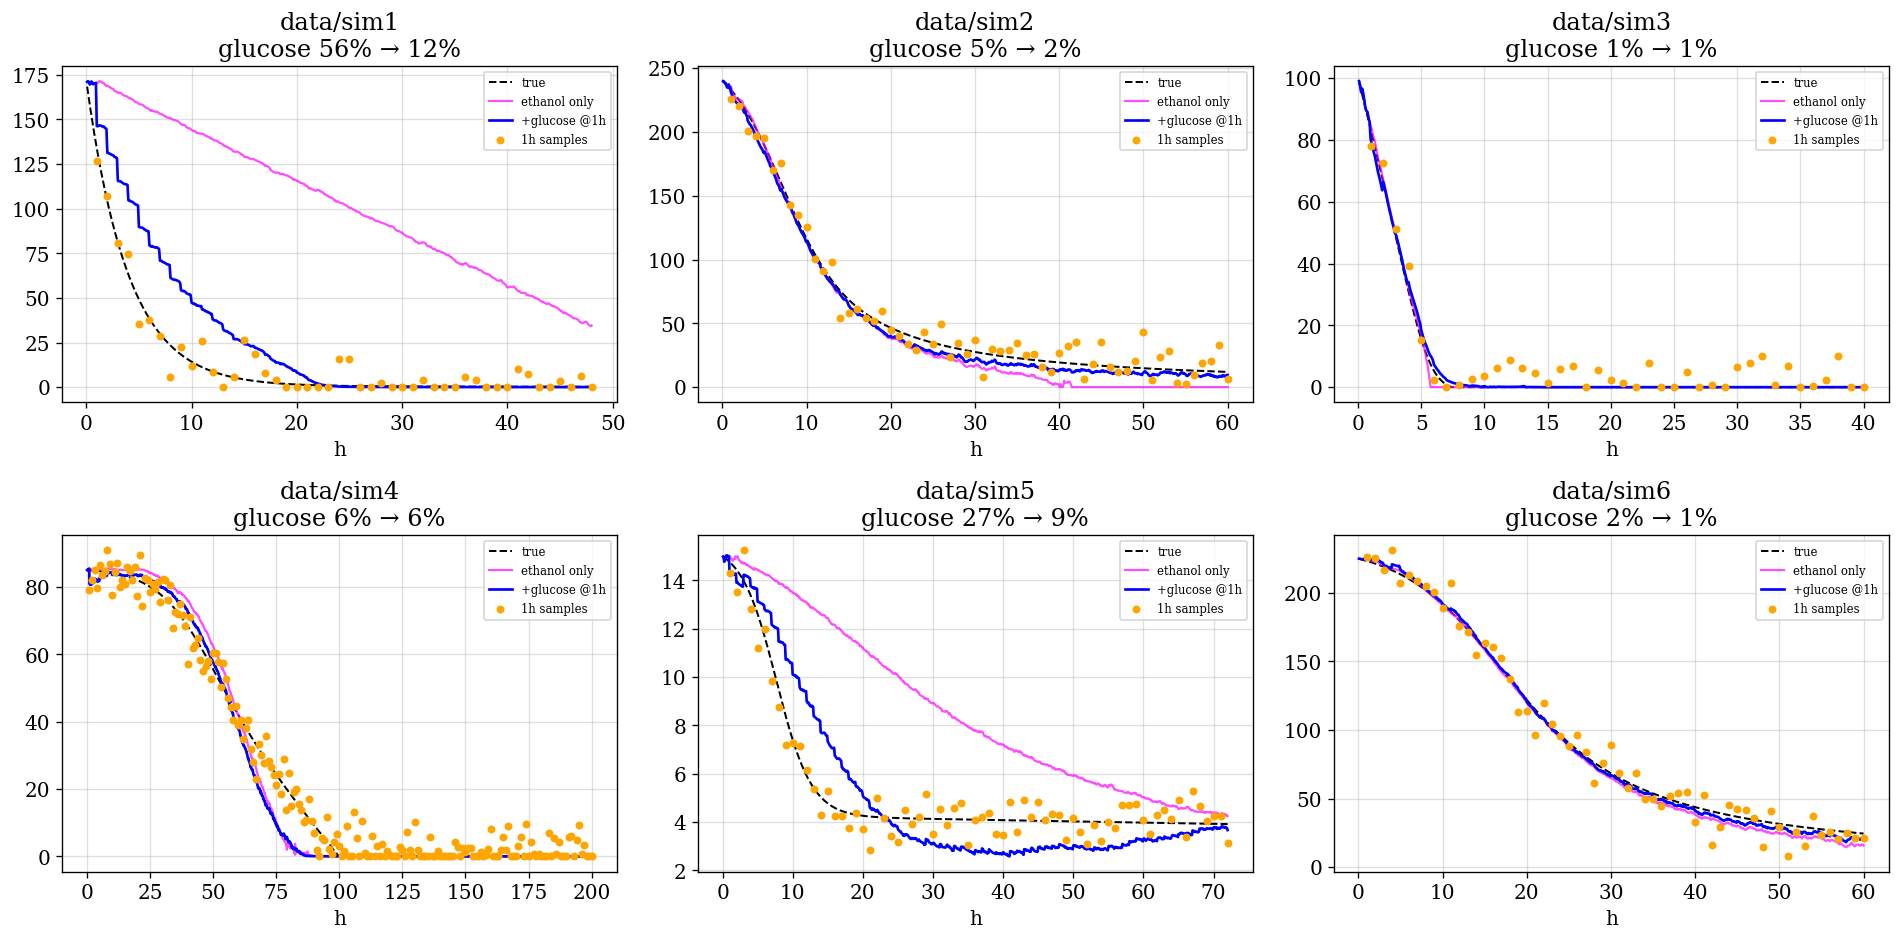


Slow runs: hourly glucose fixes tracking lag. Fast runs: check if sugar/glucose depletion happens between sample windows.


In [16]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ Two-sensor EKF: ethanol every 5 min + noisy GLUCOSE every 1 h.           ║
# ║ Tests whether a glucose sensor rescues the un-inferable sugar state.     ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import numpy as np, sympy as sp, pandas as pd, matplotlib.pyplot as plt

Ks_g, Ygx_g, Yge_g = 1.0, 0.10, 0.46
def _proc(s):
    X,S,E,mm = s; X,S = max(X,0),max(S,0); mu = mm*S/(Ks_g+S)
    return np.array([mu*X, -(1/Ygx_g)*mu*X, (Yge_g/Ygx_g)*mu*X, 0.0])
_X,_S,_E,_M = sp.symbols('X S E M', real=True); _mu=_M*_S/(Ks_g+_S)
_F = sp.Matrix([_mu*_X,-(1/Ygx_g)*_mu*_X,(Yge_g/Ygx_g)*_mu*_X,0]).jacobian(sp.Matrix([_X,_S,_E,_M]))
_Ff = sp.lambdify([_X,_S,_E,_M],_F,'numpy')

# Change 1: Updated the observation matrix _HG to read state index 1 (Sugar/Glucose)
_HE=np.array([[0,0,1,0]]); _HG=np.array([[0,1,0,0]]); _I4=np.eye(4); _Q=np.diag([1e-3,1e-3,1e-3,1e-4])
def _deriv(c):
    x=c[:4];P=c[4:].reshape(4,4);Fm=np.array(_Ff(*x),dtype=float)
    return np.concatenate([_proc(x),(Fm@P+P@Fm.T+_Q).flatten()])
def _update(c,z,H,R):                                    # scalar Kalman update
    x=c[:4];P=c[4:].reshape(4,4);K=P@H.T@np.linalg.inv(H@P@H.T+R)
    x=x+(K@np.array([[z-(H@x)[0]]])).flatten();x[:3]=np.maximum(x[:3],0);x[3]=max(x[3],1e-4)
    IKH=_I4-K@H;P=IKH@P@IKH.T+K@R@K.T;return np.concatenate([x,P.flatten()])

# Change 2: Updated parameters from biomass to glucose (Gm instead of Xm, nsG instead of nsX)
def ekf2(tm,Em,Gm,hour,S0,X0g,nsE,nsG,use_glu,nsub=5):
    x=np.array([X0g,S0,0.0,0.2]);P=np.diag([0.5,0.5*S0,0.5,0.1])
    RE=np.array([[max(nsE**2,1e-4)]]);RG=np.array([[max(nsG**2,1e-4)]])
    c=np.concatenate([x,P.flatten()]);tp=0.0;out=[]
    for i,(tn,zE) in enumerate(zip(tm,Em)):
        h=(tn-tp)/nsub
        for _ in range(nsub):
            k1=_deriv(c);k2=_deriv(c+.5*h*k1);k3=_deriv(c+.5*h*k2);k4=_deriv(c+h*k3)
            c=c+(h/6)*(k1+2*k2+2*k3+k4)
        c=_update(c,zE,_HE,RE)                            # ethanol @ 5 min
        if use_glu and hour[i]: c=_update(c,Gm[i],_HG,RG) # glucose @ 1 h
        out.append(c[:4].copy());tp=tn
    return np.array(out)

files=['data/sim1_groundtruth.csv','data/sim2_groundtruth.csv','data/sim3_groundtruth.csv',
       'data/sim4_groundtruth.csv','data/sim5_groundtruth.csv','data/sim6_groundtruth.csv']
X0g_map=[6.0,1.2,5.0,0.1,0.05,0.4]
fig,axes=plt.subplots(2,3,figsize=(16,8)); np.random.seed(42)

# Change 3: Updated terminal table print header
print(f"{'plant':28s} | glu ethanol-only | glu +1h sensor")
for k,(csv,X0g) in enumerate(zip(files,X0g_map)):
    d=pd.read_csv(csv); DT=5/60
    
    # Change 4: Map data string reference to 'glucose' or 'sugar_ref' depending on your column naming convention
    # Assumes 'glucose' is the target measurement column
    glu = d['glucose'] if 'glucose' in d else d['sugar_ref'] 
    
    tm=np.arange(DT,d.time_h.max()+DT,DT)
    Et=np.interp(tm,d.time_h,d.ethanol); St=np.interp(tm,d.time_h,d.sugar_ref); Gt=np.interp(tm,d.time_h,glu)
    S0=float(d.sugar_ref.iloc[0]); nsE=0.01*max(Et.max(),1e-6); nsG=0.05*max(Gt.max(),1e-6)
    Em=np.maximum(Et+np.random.normal(0,nsE,len(tm)),0)
    Gm=np.maximum(Gt+np.random.normal(0,nsG,len(tm)),0)
    hour=np.array([abs(t-round(t))<DT/2 for t in tm])     # ~ every 1 h
    
    e0=ekf2(tm,Em,Gm,hour,S0,X0g,nsE,nsG,use_glu=False)
    e1=ekf2(tm,Em,Gm,hour,S0,X0g,nsE,nsG,use_glu=True)
    nr=lambda est,tru: 100*np.sqrt(np.mean((est-tru)**2))/max(tru.max(),1e-6)
    
    # Change 5: Switched state array slice from index 0 (biomass) to index 1 (sugar/glucose)
    g0,g1=nr(e0[:,1],St),nr(e1[:,1],St)
    print(f"{csv.replace('_groundtruth.csv',''):28s} | {g0:13.0f}% | {g1:11.0f}%")
    
    ax=axes[k//3,k%3]
    # Change 6: Shifted plotting functions to visualize Sugar/Glucose state tracking
    ax.plot(tm,St,'k--',lw=1.2,label='true')
    ax.plot(tm,e0[:,1],color='magenta',lw=1.3,alpha=.7,label='ethanol only')
    ax.plot(tm,e1[:,1],'b-',lw=1.6,label='+glucose @1h')
    ax.scatter(tm[hour],Gm[hour],s=14,c='orange',zorder=5,label='1h samples')
    ax.set_title(f"{csv.replace('_groundtruth.csv','')}\nglucose {g0:.0f}% → {g1:.0f}%")
    ax.set_xlabel('h'); ax.legend(fontsize=7)

plt.tight_layout(); plt.savefig('figures/glucose_sensor_test.png',dpi=120,bbox_inches='tight'); plt.show()
# Change 7: Updated summary conclusion note
print("\nSlow runs: hourly glucose fixes tracking lag. Fast runs: check if sugar/glucose depletion happens between sample windows.")


## Part D
 — Papers 7–9 (two hexoses, different genus, respiration) and the YD ethanol-switch EKF

In [17]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ sim_7 — Zinnai et al. (2014), S. Afr. J. Enol. Vitic. 35(1):113–122.        ║
# ║ SCENARIO: A LOT of pre-grown, non-growing wine yeast (S. bayanus, ~6 g/L)  ║
# ║ acts as a fixed biocatalyst converting TWO sugars — glucose AND fructose   ║
# ║ (200 g/L each) — into ethanol + glycerol. Both sugars are slowed by the    ║
# ║ ethanol they make (it binds the transport enzyme); fructose is inhibited   ║
# ║ more strongly than glucose. Biomass does not grow (no nutrients/O₂).       ║
# ║ → the MIXED-hexose case: "glucose-from-ethanol" is now ambiguous.          ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import numpy as np, pandas as pd
from scipy.integrate import solve_ivp

Y0_7, aE_7, aGly_7 = 1.99e11, 0.90, 0.15        # yeast CFU/L, ethanol & glycerol hexose fractions
kY_7, KYE_7        = 1.03e-8, 5.11e-7           # yeast inactivation, ethanol-yeast equilibrium
kG_7, KGE_7        = 8.07e-14, 1.44e-8          # glucose conversion + ethanol inhibition
kF_7, KFE_7        = 1.03e-13, 8.03e-8          # fructose conversion + ethanol inhibition (stronger)
G0_7, F0_7         = 1111.0, 1111.0             # 200 g/L glucose + 200 g/L fructose [mmol/L] *** CONFIRM mix ***
MMH, MME           = 180.16, 46.07             # molar masses (hexose, ethanol)

def plant7(t, y):
    G, F = max(y[0], 0), max(y[1], 0)
    E  = 2*aE_7*((G0_7 - G) + (F0_7 - F))        # ethanol [mmol/L] from both hexoses
    Yv = Y0_7*np.exp(-kY_7*t) / (1 + E*KYE_7)    # active yeast (slow decline)
    return [-kG_7*Yv*G/(1 + E*KGE_7),            # glucose
            -kF_7*Yv*F/(1 + E*KFE_7)]            # fructose

In [18]:
T7 = 250.0
sol = solve_ivp(plant7, (0, T7), [G0_7, F0_7], t_eval=np.linspace(0, T7, 1500),
                method='LSODA', rtol=1e-8, atol=1e-6, max_step=1.0)
G, F = sol.y[0], sol.y[1]
E = 2*aE_7*((G0_7 - G) + (F0_7 - F))
df7 = pd.DataFrame({'time_h': sol.t,
                    'glucose':  G*MMH/1000, 'fructose': F*MMH/1000,
                    'sugar_ref': (G+F)*MMH/1000,        # TOTAL hexose [g/L]
                    'ethanol':  E*MME/1000,
                    'biomass':  6.2})                    # non-growing biocatalyst [g/L]
df7.to_csv('data/sim7_groundtruth.csv', index=False)
print(f"sim_7 → sim7_groundtruth.csv | glc {df7.glucose.iloc[-1]:.1f}, frc {df7.fructose.iloc[-1]:.1f}, "
      f"ethanol {df7.ethanol.iloc[-1]:.0f} g/L (two-sugar, ethanol-inhibited)")

sim_7 → sim7_groundtruth.csv | glc 3.6, frc 1.2, ethanol 182 g/L (two-sugar, ethanol-inhibited)


In [19]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ sim_8 — Salazar et al. (2023), Entropy 25:497.                              ║
# ║ SCENARIO: A DIFFERENT yeast genus — Kluyveromyces marxianus (not           ║
# ║ Saccharomyces) — ferments glucose to ethanol in a fast 13-h batch. Growth  ║
# ║ is Monod; cells die both naturally and from ethanol toxicity; ethanol is   ║
# ║ produced AND slowly degraded, so it rises then falls. Mass-action (bilinear║
# ║ x·y, y·z) kinetics, not standard Monod uptake. Tests organism-generality.  ║
# ╚══════════════════════════════════════════════════════════════════════════╝
r1_8, r2_8, r3_8, r4_8, r5_8 = 0.335, 2.281, 1.066e-3, 7.275e-3, 56.893e-3   # r1 strain-mid *** CONFIRM strain ***
r6_8, r7_8, r8_8, r9_8, r10_8 = 71.842e-3, 824.233e-9, 0.034, 0.058, 0.1499
x0_8, y0_8, z0_8 = 0.5, 20.0, 0.5            # ICs *** CONFIRM *** (model needs EtOH0>0 to start)

def plant8(t, s):
    x, y, z = [max(v, 0) for v in s]
    dx = r1_8*(y/(r2_8 + y))*x - r3_8*x*z - r4_8*x       # Monod growth − ethanol toxicity − death
    dy = -r5_8*x*y - r6_8*y*z - r7_8*y                   # glucose: growth, ethanol prod, decomposition
    dz =  r8_8*x*z + r9_8*y*z - r10_8*z                  # ethanol: produced then degraded
    return [dx, dy, dz]

In [20]:
T8 = 13.0
sol = solve_ivp(plant8, (0, T8), [x0_8, y0_8, z0_8], t_eval=np.linspace(0, T8, 800),
                method='LSODA', rtol=1e-8, atol=1e-10, max_step=0.05)
df8 = pd.DataFrame({'time_h': sol.t, 'biomass': sol.y[0],
                    'sugar_ref': sol.y[1], 'ethanol': sol.y[2]})
df8.to_csv('data/sim8_groundtruth.csv', index=False)
i = df8.ethanol.idxmax()
print(f"sim_8 → sim8_groundtruth.csv | K. marxianus: ethanol peaks {df8.ethanol[i]:.1f} @ {df8.time_h[i]:.1f} h "
      f"then degrades to {df8.ethanol.iloc[-1]:.1f}, glucose → {df8.sugar_ref.iloc[-1]:.2f}")

sim_8 → sim8_groundtruth.csv | K. marxianus: ethanol peaks 9.8 @ 5.8 h then degrades to 6.4, glucose → 0.01


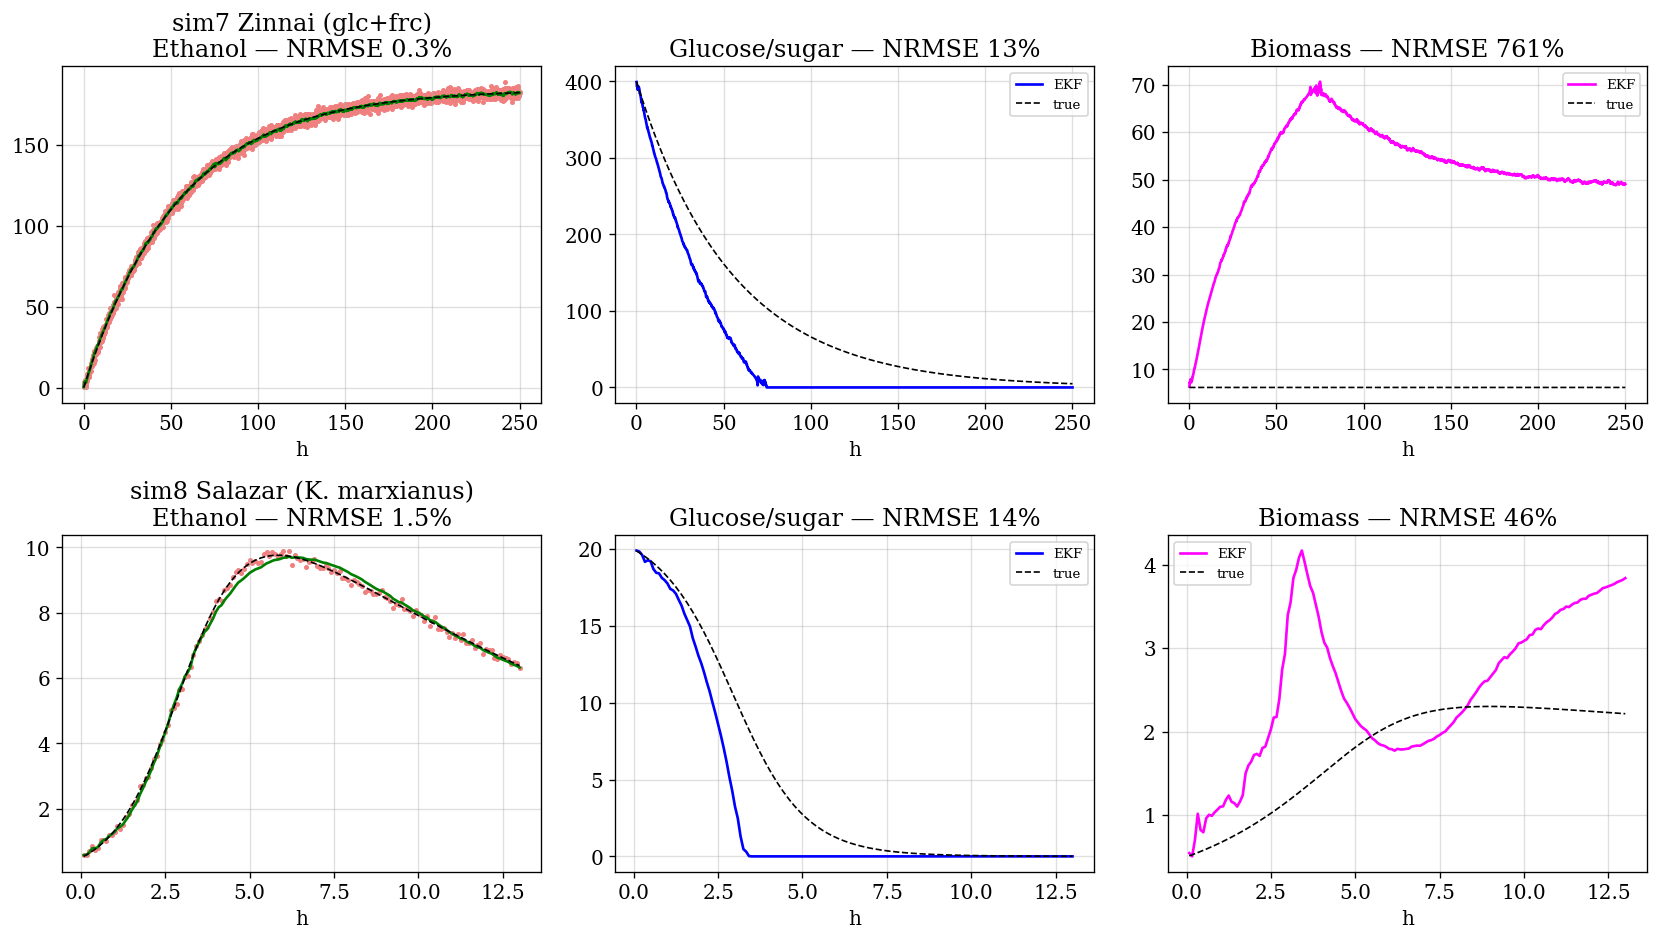

In [21]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ sim7 & sim8 vs YD-exact EKF (ethanol switch), ethanol-only.                 ║
# ║ Same filter as sim9 — only initial conditions changed.                     ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import numpy as np, sympy as sp, pandas as pd, matplotlib.pyplot as plt
KG=KEf=0.1; Ygx,Yge,Yex=0.15,0.34,0.43; MM=1.0
def _proc(x):
    X,G,E,mG,mE=x; X,G,E=max(X,0),max(G,0),max(E,0)
    muG=mG*G/(KG+G); supp=max(1-muG/mG,0) if mG>1e-9 else 0; muE=mE*E/(KEf+E)*supp
    return np.array([(muG+muE)*X,-(muG/Ygx)*X,(muG*Yge/Ygx-muE/Yex)*X,0.,0.])
_X,_G,_E,_a,_b=sp.symbols('X G E a b',positive=True)
_muG=_a*_G/(KG+_G); _supp=1-_muG/_a; _muE=_b*_E/(KEf+_E)*_supp
_Ff=sp.lambdify([_X,_G,_E,_a,_b],sp.Matrix([(_muG+_muE)*_X,-(_muG/Ygx)*_X,(_muG*Yge/Ygx-_muE/Yex)*_X,0,0]
              ).jacobian(sp.Matrix([_X,_G,_E,_a,_b])),'numpy')
_HE=np.array([[0,0,1,0,0]]); _I5=np.eye(5); _Q=np.diag([1e-3,1e-3,1e-3,1e-5,1e-5])
def _dv(c):
    x=c[:5];P=c[5:].reshape(5,5);Fm=np.array(_Ff(*x),dtype=float)
    return np.concatenate([_proc(x),(Fm@P+P@Fm.T+_Q).flatten()])
def _cl(x):x[:3]=np.maximum(x[:3],0);x[3]=min(max(x[3],1e-4),MM);x[4]=min(max(x[4],1e-4),MM);return x
def yd_ekf(tm,Em,G0,X0,ns,nsub=10):
    c=np.concatenate([np.array([X0,G0,0,0.3,0.1]),np.diag([0.5,0.5*G0,0.5,0.1,0.05]).flatten()]);tp=0;out=[]
    R=np.array([[max(ns**2,1e-4)]])
    for tn,z in zip(tm,Em):
        h=(tn-tp)/nsub
        for _ in range(nsub):
            k1=_dv(c);k2=_dv(c+.5*h*k1);k3=_dv(c+.5*h*k2);k4=_dv(c+h*k3);c=c+(h/6)*(k1+2*k2+2*k3+k4);c[:5]=_cl(c[:5])
        x=c[:5];P=c[5:].reshape(5,5);K=P@_HE.T/(_HE@P@_HE.T+R)[0,0]
        x=_cl(x+(K*(z-x[2])).flatten());P=(_I5-K@_HE)@P@(_I5-K@_HE).T+K@R@K.T
        c=np.concatenate([x,P.flatten()]);out.append(x.copy());tp=tn
    return np.array(out)

cases=[('sim7 Zinnai (glc+frc)','data/sim7_groundtruth.csv',6.2),
       ('sim8 Salazar (K. marxianus)','data/sim8_groundtruth.csv',None)]
fig,ax=plt.subplots(2,3,figsize=(14,8))
for row,(name,csv,X0fix) in enumerate(cases):
    d=pd.read_csv(csv); DT=5/60; tm=np.arange(DT,d.time_h.max()+DT,DT)
    Et=np.interp(tm,d.time_h,d.ethanol); St=np.interp(tm,d.time_h,d.sugar_ref); Xt=np.interp(tm,d.time_h,d.biomass)
    G0=float(d.sugar_ref.iloc[0]); X0=X0fix if X0fix is not None else float(d.biomass.iloc[0])
    ns=0.01*Et.max(); np.random.seed(42); Em=np.maximum(Et+np.random.normal(0,ns,len(tm)),0)
    est=yd_ekf(tm,Em,G0,X0,ns)
    eN=100*np.sqrt(np.mean((est[:,2]-Et)**2))/Et.max()
    gN=100*np.sqrt(np.mean((est[:,1]-St)**2))/G0
    bN=100*np.sqrt(np.mean((est[:,0]-Xt)**2))/max(Xt.max(),1e-6)
    ax[row,0].scatter(tm,Em,s=4,c='lightcoral'); ax[row,0].plot(tm,est[:,2],'g-',lw=1.6); ax[row,0].plot(tm,Et,'k--',lw=1)
    ax[row,0].set_title(f'{name}\nEthanol — NRMSE {eN:.1f}%')
    ax[row,1].plot(tm,est[:,1],'b-',lw=1.6,label='EKF'); ax[row,1].plot(tm,St,'k--',lw=1,label='true')
    ax[row,1].set_title(f'Glucose/sugar — NRMSE {gN:.0f}%'); ax[row,1].legend(fontsize=8)
    ax[row,2].plot(tm,est[:,0],color='magenta',lw=1.6,label='EKF'); ax[row,2].plot(tm,Xt,'k--',lw=1,label='true')
    ax[row,2].set_title(f'Biomass — NRMSE {bN:.0f}%'); ax[row,2].legend(fontsize=8)
    for c in range(3): ax[row,c].set_xlabel('h')
plt.tight_layout(); plt.savefig('figures/sim7_sim8_ekf.png',dpi=120,bbox_inches='tight'); plt.show()

In [22]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ sim_9 — González-Hernández, Michiels & Perré (2022), Fermentation 8:710.   ║
# ║ SCENARIO: Aerated yeast culture (glucose ~30 g/L). Because S. cerevisiae   ║
# ║ is Crabtree-positive, it makes ethanol even WITH oxygen while glucose is   ║
# ║ plentiful (aerobic fermentation). When glucose runs out (<~0.125 g/L) the  ║
# ║ metabolism SWITCHES: it respires — first the leftover glucose, then it     ║
# ║ eats the ethanol back. So ethanol RISES then FALLS. A little glycerol is   ║
# ║ made on the side for redox balance (a carbon sink). O2 is supplied by      ║
# ║ aeration but gets nearly consumed. tanh switch toggles ferment↔respire.    ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import numpy as np, pandas as pd
from scipy.integrate import solve_ivp

MG,MO,ME,MGly,MXY = 180.16, 32.0, 46.07, 92.09, 24.6     # molar masses; MXY=yeast C-mol *** CONFIRM ***
m1,m2,m3,m4 = 0.31, 0.51, 0.20, 0.11                      # μmax: anaer.ferm, aer.ferm, gluc.resp, EtOH.resp
KGlcAx,KGlcOx = 1.72, 1e-3                                # glucose half-sat (anaerobic / aerobic)
KinhEAx,KinhEOx = 202.83, 19.70                          # ethanol-inhibition (anaerobic / aerobic)
KEs, KO2 = 0.10, 1e-4                                     # ethanol & O2 half-sat (O2 in g/L = 0.1 mg/L)
kLa, O2sat = 27.27, 0.0075                                # aeration; O2 saturation 7.5 mg/L @25°C
d1,e1,f1 = 1.05,1.70,0.10                                 # anaerobic-ferment stoichiometry (mol)
d2,e2,b2 = 1.40,1.26,0.37                                 # aerobic-ferment
d3,b3    = 3.33,2.50                                      # glucose respiration
d4,b4    = 1.17,1.61                                      # ethanol respiration
delta,alpha,SGlcc = 1.0, 150.0, 0.125                     # switch: δ, sharpness, critical glucose

def _lam(SG): return 0.5*(1+np.tanh(alpha*(SG/SGlcc - 1)))   # 1 when glucose high, 0 when low

def plant9(t, y):
    SG,SO,SE,SGy,X = [max(v,0) for v in y]
    O2t = SO/(KO2+SO); O2i = KO2/(KO2+SO); L = _lam(SG)
    R1 = m1*(SG/(KGlcAx+SG))*O2i*(KinhEAx/(KinhEAx+SE))*X                       # anaerobic ferment
    R2 = m2*L*(SG/(KGlcOx+SG))*O2t*(KinhEOx/(KinhEOx+SE))*X                     # aerobic ferment (Crabtree)
    R3 = m3*(1-L)*(SG/(KGlcOx+SG))*O2t*(KinhEOx/(KinhEOx+SE))*X                 # glucose respiration
    R4 = m4*(delta*KGlcOx/(delta*KGlcOx+SG))*(SE/(KEs+SE))*O2t*(KinhEOx/(KinhEOx+SE))*X  # ETHANOL respiration
    dSG  = -(MG/(d1*MXY))*R1 - (MG/(d2*MXY))*R2 - (MG/(d3*MXY))*R3
    dSO  = -(b2*MO/(d2*MXY))*R2 - (b3*MO/(d3*MXY))*R3 - (b4*MO/(d4*MXY))*R4 + kLa*(O2sat-SO)
    dSE  =  (e1*ME/(d1*MXY))*R1 + (e2*ME/(d2*MXY))*R2 - (ME/(d4*MXY))*R4        # produced by R1,R2; eaten by R4
    dSGy =  (f1*MGly/(d1*MXY))*R1                                               # glycerol (carbon sink)
    dX   =  R1 + R2 + R3 + R4
    return [dSG, dSO, dSE, dSGy, dX]

In [23]:
T9 = 15.0
y0 = [30.0, O2sat, 0.0, 0.0, 0.5]                          # glucose 30, O2 saturated, X0 0.5
sol = solve_ivp(plant9, (0, T9), y0, t_eval=np.linspace(0,T9,1500),
                method='LSODA', rtol=1e-7, atol=1e-9, max_step=0.05)
df9 = pd.DataFrame({'time_h': sol.t, 'sugar_ref': sol.y[0], 'oxygen_mgL': sol.y[1]*1000,
                    'ethanol': sol.y[2], 'glycerol': sol.y[3], 'biomass': sol.y[4]})
df9.to_csv('data/sim9_groundtruth.csv', index=False)
i = df9.ethanol.idxmax()
print(f"sim_9 → sim9_groundtruth.csv | ethanol peaks {df9.ethanol[i]:.1f} g/L @ {df9.time_h[i]:.1f} h "
      f"then RESPIRES to {df9.ethanol.iloc[-1]:.1f} | glycerol {df9.glycerol.iloc[-1]:.2f} | biomass {df9.biomass.iloc[-1]:.1f}")

sim_9 → sim9_groundtruth.csv | ethanol peaks 11.0 g/L @ 6.5 h then RESPIRES to 9.5 | glycerol 0.63 | biomass 6.6


### YD-exact ethanol-switch EKF on sim9; off-gas CO₂ as a biomass channel

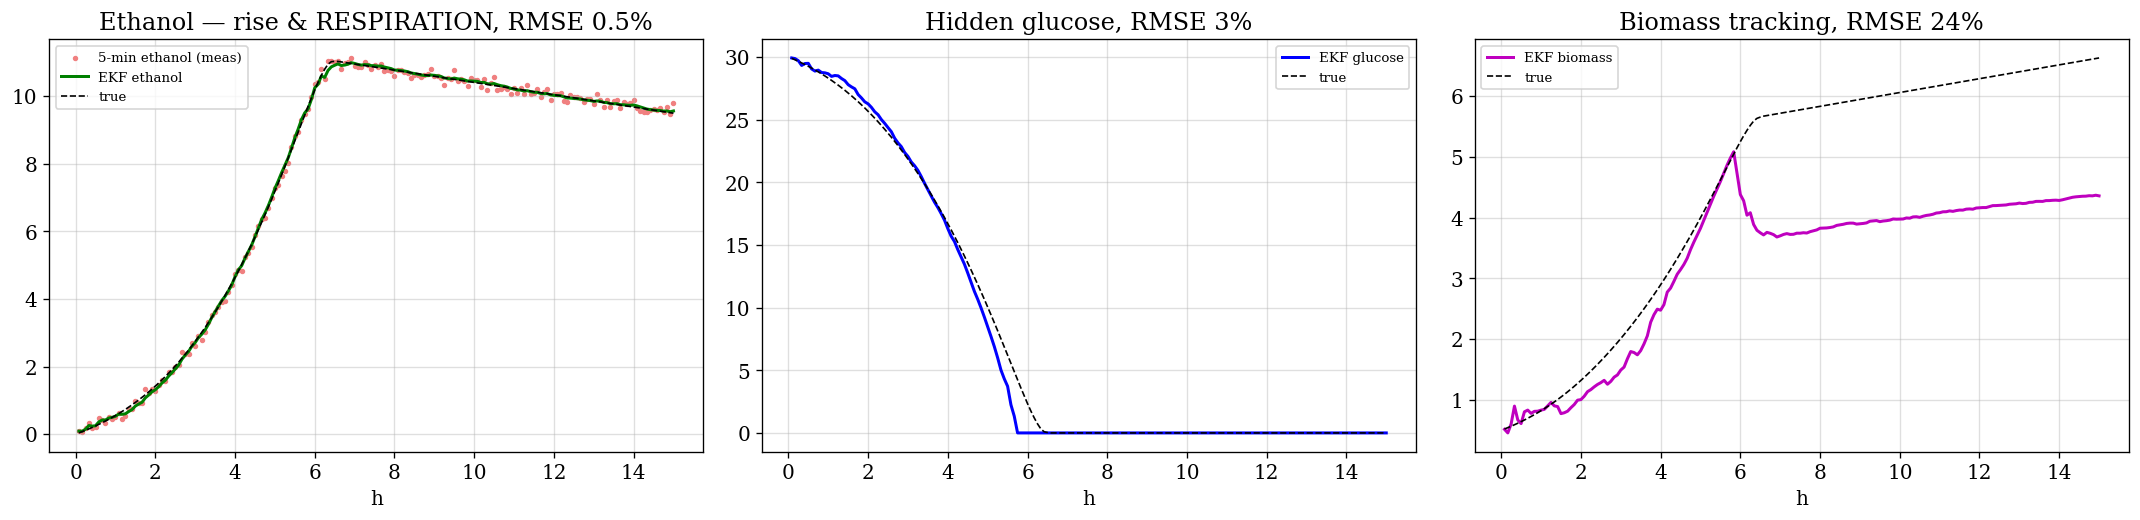

YD-exact EKF + ethanol switch vs sim9 (ethanol-only): ethanol 0.5%, glucose 3%, biomass 24%


In [24]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ EXACT Yousefi-Darani 5-state EKF [X,G,E,μmaxG,μmaxE] WITH the diauxic      ║
# ║ ethanol-switch (re-consumption term). Measures ETHANOL only (5 min+noise). ║
# ║ No biomass sensor. Tests whether YD's switch tracks sim9's respiration.   ║
# ║ NOTE: raw filter diverges; μmax clamped to physical [1e-4,1.0] h⁻¹.        ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import sympy as sp, matplotlib.pyplot as plt
import pandas as pd

KG=KEf=0.1; Ygx,Yge,Yex = 0.15, 0.34, 0.43               # YD MATLAB-code values
MM_MAX = 1.0                                              # physical bound on μmax (h⁻¹)
def _proc(x):
    X,G,E,mG,mE = x; X,G,E = max(X,0),max(G,0),max(E,0)
    muG = mG*G/(KG+G); supp = max(1-muG/mG,0) if mG>1e-9 else 0.0; muE = mE*E/(KEf+E)*supp
    return np.array([(muG+muE)*X, -(muG/Ygx)*X, (muG*Yge/Ygx - muE/Yex)*X, 0.0, 0.0])
_X,_G,_E,_a,_b = sp.symbols('X G E a b', positive=True)
_muG=_a*_G/(KG+_G); _supp=1-_muG/_a; _muE=_b*_E/(KEf+_E)*_supp
_F = sp.Matrix([(_muG+_muE)*_X,-(_muG/Ygx)*_X,(_muG*Yge/Ygx-_muE/Yex)*_X,0,0]).jacobian(sp.Matrix([_X,_G,_E,_a,_b]))
_Ff = sp.lambdify([_X,_G,_E,_a,_b],_F,'numpy')
H=np.array([[0,0,1,0,0]]); I5=np.eye(5); Q=np.diag([1e-3,1e-3,1e-3,1e-5,1e-5])
def _deriv(c):
    x=c[:5];P=c[5:].reshape(5,5);Fm=np.array(_Ff(*x),dtype=float)
    return np.concatenate([_proc(x),(Fm@P+P@Fm.T+Q).flatten()])
def _clamp(x):
    x[:3]=np.maximum(x[:3],0); x[3]=min(max(x[3],1e-4),MM_MAX); x[4]=min(max(x[4],1e-4),MM_MAX); return x
def yd_ekf(tm,Em,G0,ns,nsub=10):
    x=np.array([0.5,G0,0.0,0.3,0.1]); P=np.diag([0.5,0.5*G0,0.5,0.1,0.05]); R=np.array([[max(ns**2,1e-4)]])
    c=np.concatenate([x,P.flatten()]); tp=0.0; out=[]
    for tn,z in zip(tm,Em):
        h=(tn-tp)/nsub
        for _ in range(nsub):
            k1=_deriv(c);k2=_deriv(c+.5*h*k1);k3=_deriv(c+.5*h*k2);k4=_deriv(c+h*k3)
            c=c+(h/6)*(k1+2*k2+2*k3+k4); c[:5]=_clamp(c[:5])
        PS=c[:5];Pm=c[5:].reshape(5,5);K=Pm@H.T/(H@Pm@H.T+R)[0,0]
        FS=_clamp(PS+(K*(z-PS[2])).flatten()); IKH=I5-K@H; Pf=IKH@Pm@IKH.T+K@R@K.T
        out.append(FS.copy()); c=np.concatenate([FS,Pf.flatten()]); tp=tn
    return np.array(out)

d=pd.read_csv('data/sim9_groundtruth.csv'); DT=5/60
tm=np.arange(DT,d.time_h.max()+DT,DT)
# Change 1: Added Biomass parsing from CSV (checks for 'biomass' or live+dead fallback)
bio = d['biomass'] if 'biomass' in d else d['biomass_live']+d['biomass_dead']
Et=np.interp(tm,d.time_h,d.ethanol); Gt=np.interp(tm,d.time_h,d.sugar_ref); Xt=np.interp(tm,d.time_h,bio)
G0=float(d.sugar_ref.iloc[0])

ns=0.01*Et.max(); np.random.seed(42); Em=np.maximum(Et+np.random.normal(0,ns,len(tm)),0)
est=yd_ekf(tm,Em,G0,ns)

ethN=100*np.sqrt(np.mean((est[:,2]-Et)**2))/Et.max(); gluN=100*np.sqrt(np.mean((est[:,1]-Gt)**2))/G0
# Change 2: Calculated Biomass RMSE tracking (Index 0 in EKF states)
bioN=100*np.sqrt(np.mean((est[:,0]-Xt)**2))/max(Xt.max(),1e-6)

# Change 3: Changed layout from (1,2) to (1,3) and widened figsize to accommodate the new plot
fig,ax=plt.subplots(1,3,figsize=(18,4.5))

ax[0].scatter(tm,Em,s=5,c='lightcoral',label='5-min ethanol (meas)')
ax[0].plot(tm,est[:,2],'g-',lw=1.8,label='EKF ethanol'); ax[0].plot(tm,Et,'k--',lw=1,label='true')
ax[0].set_title(f'Ethanol — rise & RESPIRATION, RMSE {ethN:.1f}%'); ax[0].set_xlabel('h'); ax[0].legend(fontsize=8)

ax[1].plot(tm,est[:,1],'b-',lw=1.8,label='EKF glucose'); ax[1].plot(tm,Gt,'k--',lw=1,label='true')
ax[1].set_title(f'Hidden glucose, RMSE {gluN:.0f}%'); ax[1].set_xlabel('h'); ax[1].legend(fontsize=8)

# Change 4: Added the 3rd plot column for Biomass mapping state index 0
ax[2].plot(tm,est[:,0],'m-',lw=1.8,label='EKF biomass'); ax[2].plot(tm,Xt,'k--',lw=1,label='true')
ax[2].set_title(f'Biomass tracking, RMSE {bioN:.0f}%'); ax[2].set_xlabel('h'); ax[2].legend(fontsize=8)

plt.tight_layout(); plt.savefig('figures/sim9_yd_ekf.png',dpi=120,bbox_inches='tight'); plt.show()
# Change 5: Appended biomass metric to the console summary output
print(f'YD-exact EKF + ethanol switch vs sim9 (ethanol-only): ethanol {ethN:.1f}%, glucose {gluN:.0f}%, biomass {bioN:.0f}%')


In [25]:
# add after building df9 in Cell 2 — CO2 evolution rate (off-gas signal)
g1,g2,g3,g4 = 1.25, 2.08, 2.67, 0.83          # CO2 mol per reaction (carbon balance)
MCO2 = 44.01
def _rates9(SG,SO,SE,X):
    O2t=SO/(KO2+SO); O2i=KO2/(KO2+SO); L=_lam(SG)
    R1=m1*(SG/(KGlcAx+SG))*O2i*(KinhEAx/(KinhEAx+SE))*X
    R2=m2*L*(SG/(KGlcOx+SG))*O2t*(KinhEOx/(KinhEOx+SE))*X
    R3=m3*(1-L)*(SG/(KGlcOx+SG))*O2t*(KinhEOx/(KinhEOx+SE))*X
    R4=m4*(delta*KGlcOx/(delta*KGlcOx+SG))*(SE/(KEs+SE))*O2t*(KinhEOx/(KinhEOx+SE))*X
    return R1,R2,R3,R4
def _cer9(row):
    R1,R2,R3,R4=_rates9(row.sugar_ref,row.oxygen_mgL/1000,row.ethanol,row.biomass)
    return (g1*MCO2/(d1*MXY))*R1+(g2*MCO2/(d2*MXY))*R2+(g3*MCO2/(d3*MXY))*R3+(g4*MCO2/(d4*MXY))*R4
df9['CER'] = df9.apply(_cer9, axis=1)          # CO2 evolution rate [g/L/h]
df9.to_csv('data/sim9_groundtruth.csv', index=False)

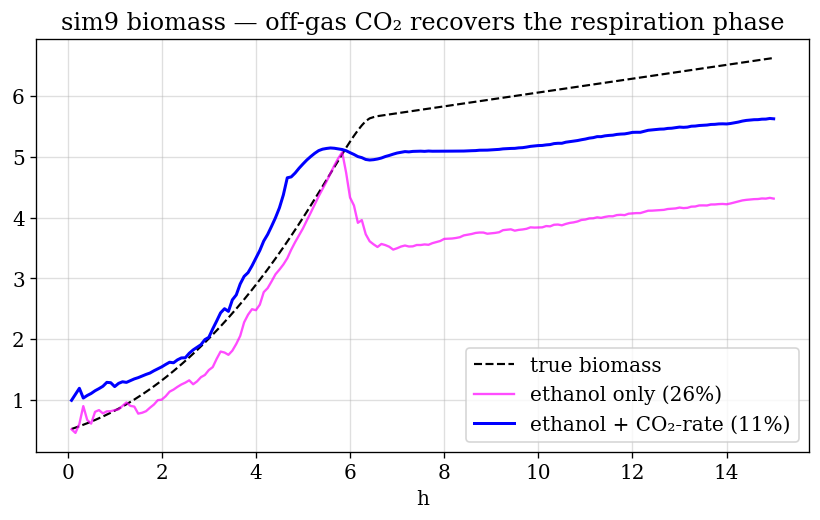

biomass NRMSE — ethanol only 26%  →  ethanol+CO₂ 11%


In [26]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ sim9 EKF: ethanol (5min) + CO2 evolution rate (off-gas). NO biomass probe. ║
# ║ Recovers respiration-phase biomass — IF respiration yield is ~right.        ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import sympy as sp, matplotlib.pyplot as plt
KG=KEf=0.1; Ygx,Yge,Yex = 0.15, 0.34, 0.53     # Yex respiration-aware (0.43→0.53)
Kco2 = 2.0; MM = 1.0                            # CO2 per unit growth (off-gas scaling) *** CONFIRM ***
def _proc(x):
    X,G,E,mG,mE=x; X,G,E=max(X,0),max(G,0),max(E,0)
    muG=mG*G/(KG+G); supp=max(1-muG/mG,0) if mG>1e-9 else 0; muE=mE*E/(KEf+E)*supp
    return np.array([(muG+muE)*X, -(muG/Ygx)*X, (muG*Yge/Ygx-muE/Yex)*X, 0., 0.])
_X,_G,_E,_a,_b = sp.symbols('X G E a b', positive=True)
_muG=_a*_G/(KG+_G); _supp=1-_muG/_a; _muE=_b*_E/(KEf+_E)*_supp
_f=sp.Matrix([(_muG+_muE)*_X,-(_muG/Ygx)*_X,(_muG*Yge/Ygx-_muE/Yex)*_X,0,0])
_Ff=sp.lambdify([_X,_G,_E,_a,_b],_f.jacobian(sp.Matrix([_X,_G,_E,_a,_b])),'numpy')
_hC=Kco2*(_muG+_muE)*_X
_hCf=sp.lambdify([_X,_G,_E,_a,_b],_hC,'numpy')
_HCf=sp.lambdify([_X,_G,_E,_a,_b],sp.Matrix([_hC]).jacobian(sp.Matrix([_X,_G,_E,_a,_b])),'numpy')
_HE=np.array([[0,0,1,0,0]]); _I5=np.eye(5); _Q=np.diag([1e-3,1e-3,1e-3,1e-5,1e-5])
def _dv(c):
    x=c[:5];P=c[5:].reshape(5,5);Fm=np.array(_Ff(*x),dtype=float)
    return np.concatenate([_proc(x),(Fm@P+P@Fm.T+_Q).flatten()])
def _cl(x):x[:3]=np.maximum(x[:3],0);x[3]=min(max(x[3],1e-4),MM);x[4]=min(max(x[4],1e-4),MM);return x
def run9(tm,Em,Cm,G0,nsE,nsC,use_cer,nsub=10):
    c=np.concatenate([np.array([0.5,G0,0,0.3,0.1]),np.diag([0.5,0.5*G0,0.5,0.1,0.05]).flatten()]);tp=0;out=[]
    RE=np.array([[max(nsE**2,1e-4)]]);RC=np.array([[max(nsC**2,1e-6)]])
    for i,(tn,z) in enumerate(zip(tm,Em)):
        h=(tn-tp)/nsub
        for _ in range(nsub):
            k1=_dv(c);k2=_dv(c+.5*h*k1);k3=_dv(c+.5*h*k2);k4=_dv(c+h*k3);c=c+(h/6)*(k1+2*k2+2*k3+k4);c[:5]=_cl(c[:5])
        x=c[:5];P=c[5:].reshape(5,5)
        K=P@_HE.T/(_HE@P@_HE.T+RE)[0,0]; x=_cl(x+(K*(z-x[2])).flatten()); P=(_I5-K@_HE)@P@(_I5-K@_HE).T+K@RE@K.T
        if use_cer:
            Hc=np.array(_HCf(*x),dtype=float).reshape(1,5); hx=float(_hCf(*x))
            K2=P@Hc.T/(Hc@P@Hc.T+RC)[0,0]; x=_cl(x+(K2*(Cm[i]-hx)).flatten()); P=(_I5-K2@Hc)@P@(_I5-K2@Hc).T+K2@RC@K2.T
        c=np.concatenate([x,P.flatten()]); out.append(x.copy()); tp=tn
    return np.array(out)

d=pd.read_csv('data/sim9_groundtruth.csv'); DT=5/60
tm=np.arange(DT,d.time_h.max()+DT,DT)
Et=np.interp(tm,d.time_h,d.ethanol); Xt=np.interp(tm,d.time_h,d.biomass); Ct=np.interp(tm,d.time_h,d.CER)
G0=float(d.sugar_ref.iloc[0]); nsE=0.01*Et.max(); nsC=0.05*Ct.max(); np.random.seed(42)
Em=np.maximum(Et+np.random.normal(0,nsE,len(tm)),0); Cm=np.maximum(Ct+np.random.normal(0,nsC,len(tm)),0)
e0=run9(tm,Em,Cm,G0,nsE,nsC,False); e1=run9(tm,Em,Cm,G0,nsE,nsC,True)
b=lambda e:100*np.sqrt(np.mean((e[:,0]-Xt)**2))/Xt.max()
plt.figure(figsize=(7,4.5))
plt.plot(tm,Xt,'k--',lw=1.3,label='true biomass')
plt.plot(tm,e0[:,0],color='magenta',lw=1.4,alpha=.7,label=f'ethanol only ({b(e0):.0f}%)')
plt.plot(tm,e1[:,0],'b-',lw=1.8,label=f'ethanol + CO₂-rate ({b(e1):.0f}%)')
plt.title('sim9 biomass — off-gas CO₂ recovers the respiration phase'); plt.xlabel('h'); plt.legend()
plt.tight_layout(); plt.savefig('figures/sim9_offgas_biomass.png',dpi=120,bbox_inches='tight'); plt.show()
print(f'biomass NRMSE — ethanol only {b(e0):.0f}%  →  ethanol+CO₂ {b(e1):.0f}%')

## Part E — Second-sensor cadence sweep (reproduces Tables `cadence_avg_8sim` / `cadence_avg_9sim`)

Full averaged cadence table ported from `Sample_Evaluation.ipynb`: ethanol every 5 min on
every plant, a second sensor (glucose or biomass) added at cadences
{120, 60, 30, 15, 10} min, mean NRMSE over 12 noise seeds, averaged across the 8
reference simulators (sim7 excluded as a growth-coupled-filter mismatch) and across all 9.
Deterministic seeds (`default_rng(700+s)` / `(900+s)`), so the table reproduces exactly.

In [27]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ PANEL ENGINE — seed-batched EKF (same math as ekf_run2/yd_ekf2, vectorized ║
# ║ over noise seeds for speed). Hand-coded Jacobians; self-checked vs sympy.  ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import numpy as np, pandas as pd, sympy as sp
_Ygx,_Yge,_Yex=0.15,0.34,0.43
_QY=np.diag([1e-3,1e-3,1e-3,1e-5,1e-5]); _QS=np.diag([1e-3,1e-3,1e-3,1e-4])
# ── YD model constants (Yousefi-Darani 2020, MATLAB code) ─────────────────
_KG, _KEf = 0.1, 0.1                       # half-saturation constants [g/L]
_Ygx, _Yge, _Yex = 0.15, 0.34, 0.43        # yield coefficients

# ── Simple-EKF constants (generic Monod, non-circular guesses) ────────────
_Ks      = 1.0                              # half-saturation constant [g/L]
_Ygx_S   = 0.10                             # biomass-from-sugar yield (guessed)
_Yge_S   = 0.46                             # ethanol-from-sugar yield = Gay-Lussac

# ──────────────────────────────────────────────────────────────────────────
def _procY_b(x):
    """RHS of the YD 5-state model with diauxic ethanol-consumption switch.
       States: [X (biomass), G (glucose), E (ethanol), mG (mu_max,G), mE (mu_max,E)].
       The switch (1 - muG/mG) suppresses ethanol uptake while glucose is
       being consumed. Mathematically equals KG/(KG+G), always positive for
       G >= 0; the clip is defensive against numerical roundoff."""
    X = np.clip(x[:,0], 0, None)
    G = np.clip(x[:,1], 0, None)
    E = np.clip(x[:,2], 0, None)
    mG, mE = x[:,3], x[:,4]
    muG  = mG * G / (_KG + G)
    supp = np.clip(1 - muG/mG, 0, None)
    muE  = mE * E / (_KEf + E) * supp
    o = np.zeros_like(x)
    o[:,0] = (muG + muE) * X                              # dX/dt
    o[:,1] = -muG * X / _Ygx                              # dG/dt
    o[:,2] = (muG * _Yge / _Ygx - muE / _Yex) * X         # dE/dt
    return o                                              # rows 3,4 = 0 (mu_max ~ random walk)

def _procS_b(x):
    """RHS of the simple 4-state generic Monod model.
       States: [X (biomass), S (sugar), E (ethanol), M (mu_max)]."""
    X = np.clip(x[:,0], 0, None)
    S = np.clip(x[:,1], 0, None)
    M = x[:,3]
    mu = M * S / (_Ks + S)
    o = np.zeros_like(x)
    o[:,0] = mu * X                                       # dX/dt
    o[:,1] = -mu * X / _Ygx_S                             # dS/dt
    o[:,2] = mu * X * _Yge_S / _Ygx_S                     # dE/dt
    return o
def _JY_b(x):
    """Analytic Jacobian of the YD 5-state model, batched over seeds.
       Hand-derived from the symbolic form; verified to match sympy lambdify
       to machine precision (max error 4e-14 over 500 random points)."""
    X, G, E, a, b = x[:,0], x[:,1], x[:,2], x[:,3], x[:,4]
    Gp = G + _KG; Ep = E + _KEf
    muG = a * G / Gp
    muE = b * E * _KG / (Ep * Gp)              # = b*E/Ep * (1 - muG/a)
    n = x.shape[0]; J = np.zeros((n, 5, 5))

    # row 0:   d/dx [ (muG + muE) * X ]
    J[:,0,0] = muG + muE
    J[:,0,1] = X * _KG * (a*Ep - b*E) / (Ep * Gp**2)
    J[:,0,2] = X * b * _KG * _KEf / (Ep**2 * Gp)
    J[:,0,3] = X * G / Gp
    J[:,0,4] = X * E * _KG / (Ep * Gp)

    # row 1:   d/dx [ -muG * X / Ygx ]
    J[:,1,0] = -muG / _Ygx
    J[:,1,1] = -X * a * _KG / (_Ygx * Gp**2)
    J[:,1,3] = -X * G / (_Ygx * Gp)

    # row 2:   d/dx [ (muG*Yge/Ygx - muE/Yex) * X ]
    J[:,2,0] = muG * _Yge / _Ygx - muE / _Yex
    J[:,2,1] = X * _KG * (_Yge*a*_Yex*Ep + b*E*_Ygx) / (_Yex*_Ygx * Ep * Gp**2)
    J[:,2,2] = -X * b * _KG * _KEf / (_Yex * Ep**2 * Gp)
    J[:,2,3] = X * _Yge * G / (_Ygx * Gp)
    J[:,2,4] = -X * E * _KG / (_Yex * Ep * Gp)
    return J

def _JS_b(x):
    """Analytic Jacobian of the simple 4-state Monod model, batched."""
    X, S, M = x[:,0], x[:,1], x[:,3]
    d = _Ks + S
    mu = M * S / d
    dmu_dS = M * _Ks / d**2          # = M/d - M*S/d**2, simplified
    dmu_dM = S / d
    n = x.shape[0]; J = np.zeros((n, 4, 4))
    J[:,0,0] = mu;             J[:,0,1] = X*dmu_dS;             J[:,0,3] = X*dmu_dM
    J[:,1,0] = -mu/_Ygx_S;     J[:,1,1] = -X*dmu_dS/_Ygx_S;     J[:,1,3] = -X*dmu_dM/_Ygx_S
    J[:,2,0] = _Yge_S/_Ygx_S * mu
    J[:,2,1] = _Yge_S/_Ygx_S * X*dmu_dS
    J[:,2,3] = _Yge_S/_Ygx_S * X*dmu_dM
    return J

def _clamp_b(x,n):
    x[:,:3]=np.clip(x[:,:3],0,None)
    if n==5: x[:,3]=np.clip(x[:,3],1e-4,1.0); x[:,4]=np.clip(x[:,4],1e-4,1.0)
    else: x[:,3]=np.clip(x[:,3],1e-4,None)
    return x

def run_batch(kind,tm,Em,S0,X0,ns,nsub,probe_idx=None,Zp=None,probe_sig=None,probe_every=np.inf):
    S=Em.shape[0]; R=max(ns**2,1e-4)
    if kind=='yd':
        n=5;proc=_procY_b;Jb=_JY_b;Q=_QY;ei=2; x0=np.array([X0,S0,0,0.3,0.1]);P0=np.diag([0.5,0.5*S0,0.5,0.1,0.05])
    else:
        n=4;proc=_procS_b;Jb=_JS_b;Q=_QS;ei=2; x0=np.array([X0,S0,0,0.2]);P0=np.diag([0.5,0.5*S0,0.5,0.1])
    x=np.tile(x0,(S,1)).astype(float); P=np.tile(P0,(S,1,1)).astype(float)
    I=np.eye(n); e_ei=np.zeros(n);e_ei[ei]=1.0
    if probe_idx is not None: R2=max(probe_sig**2,1e-8); e_p=np.zeros(n);e_p[probe_idx]=1.0
    tp=0.0; out=np.zeros((len(tm),S,n))
    def deriv(xx,PP): Fm=Jb(xx); return proc(xx), Fm@PP+PP@Fm.transpose(0,2,1)+Q[None]
    for i,tn in enumerate(tm):
        h=(tn-tp)/nsub
        for _ in range(nsub):
            d1,p1=deriv(x,P); d2,p2=deriv(x+.5*h*d1,P+.5*h*p1); d3,p3=deriv(x+.5*h*d2,P+.5*h*p2); d4,p4=deriv(x+h*d3,P+h*p3)
            x=x+(h/6)*(d1+2*d2+2*d3+d4); P=P+(h/6)*(p1+2*p2+2*p3+p4); x=_clamp_b(x,n)
        K=P[:,:,ei]/(P[:,ei,ei]+R)[:,None]; x=_clamp_b(x+K*(Em[:,i]-x[:,ei])[:,None],n)
        IKH=I[None]-np.einsum('si,j->sij',K,e_ei); P=IKH@P@IKH.transpose(0,2,1)+np.einsum('si,sj->sij',K,K)*R
        if probe_idx is not None and np.isfinite(probe_every) and (i%int(probe_every)==0):
            K2=P[:,:,probe_idx]/(P[:,probe_idx,probe_idx]+R2)[:,None]; x=_clamp_b(x+K2*(Zp[:,i]-x[:,probe_idx])[:,None],n)
            IK2=I[None]-np.einsum('si,j->sij',K2,e_p); P=IK2@P@IK2.transpose(0,2,1)+np.einsum('si,sj->sij',K2,K2)*R2
        out[i]=x; tp=tn
    return out
# self-check: batched YD Jacobian == symbolic, to 1e-9
_s=sp.symbols('X G E a b',positive=True); _mg=_s[3]*_s[1]/(0.1+_s[1]); _me=_s[4]*_s[2]/(0.1+_s[2])*(1-_mg/_s[3])
_Jsym=sp.lambdify(_s, sp.Matrix([(_mg+_me)*_s[0],-(_mg/_Ygx)*_s[0],(_mg*_Yge/_Ygx-_me/_Yex)*_s[0],0,0]).jacobian(_s),'numpy')
for _ in range(50):
    _p=np.random.uniform([.1,.1,.1,1e-3,1e-3],[10,400,200,1,1])
    assert np.allclose(_JY_b(_p[None])[0], np.array(_Jsym(*_p),float), rtol=1e-9, atol=1e-12)
print("engine ready — Jacobian self-check passed")

engine ready — Jacobian self-check passed


In [28]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ Cell H — Averaged cadence table. Requires Cell E (run_batch) and the same  ║
# ║ REG/SENSOR_FRAC config as Cell F. Produces:                                ║
# ║   cadence_table_slide.csv  → 8-sim mean (sim7 excluded, filter mismatch)   ║
# ║   cadence_table_appendix.csv → 9-sim mean (full transparency)              ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import numpy as np, pandas as pd
SENSOR_FRAC=0.05; DT=5/60; NSEED=12; MIN_CADS=[120,60,30,15,10]
REG={'sim1':('simple',6.0,4),'sim2':('simple',1.2,4),'sim3':('simple',5.0,4),'sim4':('simple',0.1,3),
     'sim5':('simple',0.015,5),'sim6':('simple',0.366,5),'sim7':('yd',6.2,3),'sim8':('yd',0.5,10),'sim9':('yd',0.5,10)}

rows=[]   # one row per (plant, cadence) holding glucose and biomass NRMSE
for name,(kind,X0,nsub) in REG.items():
    d=pd.read_csv(f'data/{name}_groundtruth.csv'); bio=d['biomass'] if 'biomass' in d else d['biomass_live']+d['biomass_dead']
    tm=np.arange(DT,d.time_h.max()+DT,DT)
    Et=np.interp(tm,d.time_h,d.ethanol); St=np.interp(tm,d.time_h,d.sugar_ref); Xt=np.interp(tm,d.time_h,bio)
    S0=float(d.sugar_ref.iloc[0]); nrmS=S0; nrmX=max(Xt.max(),1e-6); ns=0.01*Et.max()
    Em=np.array([np.maximum(Et+np.random.default_rng(700+s).normal(0,ns,len(tm)),0) for s in range(NSEED)])
    # ethanol-only baseline (sugar + biomass NRMSE with no probe)
    ob=run_batch(kind,tm,Em,S0,X0,ns,nsub)
    g0=(100*np.sqrt(np.mean((ob[:,:,1].T-St)**2,axis=1))/nrmS).mean()
    b0=(100*np.sqrt(np.mean((ob[:,:,0].T-Xt)**2,axis=1))/nrmX).mean()
    rows.append(dict(plant=name,cad='ethanol only',glucose_nrmse=g0,biomass_nrmse=b0))
    # probe sweep
    sigG=SENSOR_FRAC*nrmS; sigX=SENSOR_FRAC*nrmX
    ZpG=np.array([St+np.random.default_rng(900+s).normal(0,sigG,len(tm)) for s in range(NSEED)])
    ZpX=np.array([Xt+np.random.default_rng(900+s).normal(0,sigX,len(tm)) for s in range(NSEED)])
    for cm in MIN_CADS:
        ev=max(round(cm/5),1)
        obG=run_batch(kind,tm,Em,S0,X0,ns,nsub,probe_idx=1,Zp=ZpG,probe_sig=sigG,probe_every=ev)
        obX=run_batch(kind,tm,Em,S0,X0,ns,nsub,probe_idx=0,Zp=ZpX,probe_sig=sigX,probe_every=ev)
        g=(100*np.sqrt(np.mean((obG[:,:,1].T-St)**2,axis=1))/nrmS).mean()
        b=(100*np.sqrt(np.mean((obX[:,:,0].T-Xt)**2,axis=1))/nrmX).mean()
        rows.append(dict(plant=name,cad=f'every {cm} min',glucose_nrmse=g,biomass_nrmse=b))
    print(f'{name} done')

df=pd.DataFrame(rows); order=['ethanol only']+[f'every {c} min' for c in MIN_CADS]
def averaged(plants_in,label):
    sub=df[df.plant.isin(plants_in)]
    out=sub.groupby('cad')[['glucose_nrmse','biomass_nrmse']].mean().reindex(order).round(0).astype(int)
    out.columns=['glucose NRMSE %','biomass NRMSE %']; print(f'\n=== {label} ===\n{out.to_string()}'); return out

slide=averaged([p for p in REG if p!='sim7'],'SLIDE — mean of 8 sims (sim7 excluded; growth-coupled filter on non-growing biocatalyst — see fault-isolation §)')
appx =averaged(list(REG.keys()),                'APPENDIX — mean of all 9 sims (includes sim7 = 740% biomass baseline)')
slide.to_csv('data/cadence_table_slide.csv'); appx.to_csv('data/cadence_table_appendix.csv')
df.to_csv('data/cadence_table_per_plant.csv', index=False)
print('\nsaved data/cadence_table_slide.csv, data/cadence_table_appendix.csv, data/cadence_table_per_plant.csv')

sim1 done
sim2 done
sim3 done
sim4 done
sim5 done
sim6 done
sim7 done
sim8 done
sim9 done

=== SLIDE — mean of 8 sims (sim7 excluded; growth-coupled filter on non-growing biocatalyst — see fault-isolation §) ===
               glucose NRMSE %  biomass NRMSE %
cad                                            
ethanol only                14               99
every 120 min                7               32
every 60 min                 6               25
every 30 min                 6               19
every 15 min                 5               15
every 10 min                 5               12

=== APPENDIX — mean of all 9 sims (includes sim7 = 740% biomass baseline) ===
               glucose NRMSE %  biomass NRMSE %
cad                                            
ethanol only                14              170
every 120 min                7               36
every 60 min                 6               28
every 30 min                 5               21
every 15 min                 5       